## Tools for modern macroeconometrics

## Germany – VAR Model

### The term paper

#### Václav Šmíro
---

In [7]:
library(fredr) #api FRED
library(ecb)   #api ECB
library(RJDemetra) # to solve seasonallity

In [58]:
getwd()

[1] "/Users/smirovaclav/Documents/tools_macro"

In [40]:
library(dplyr, warn.conflicts = FALSE)
library(lubridate)
library(xts)
library(ggplot2) 
library(mFilter)
library(tsbox)
library(forecast)
library(vars)
library(tseries)
library(readr)
library(svars)

In [8]:
fred_key <- "fill_key_here"
fredr_set_key(fred_key)

In [10]:
options(repr.plot.width = 18, repr.plot.height = 6)

## Europe Brent Spot Price
https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=pet&s=rbrte&f=m

[1] "1987-05-01" "2026-03-01"

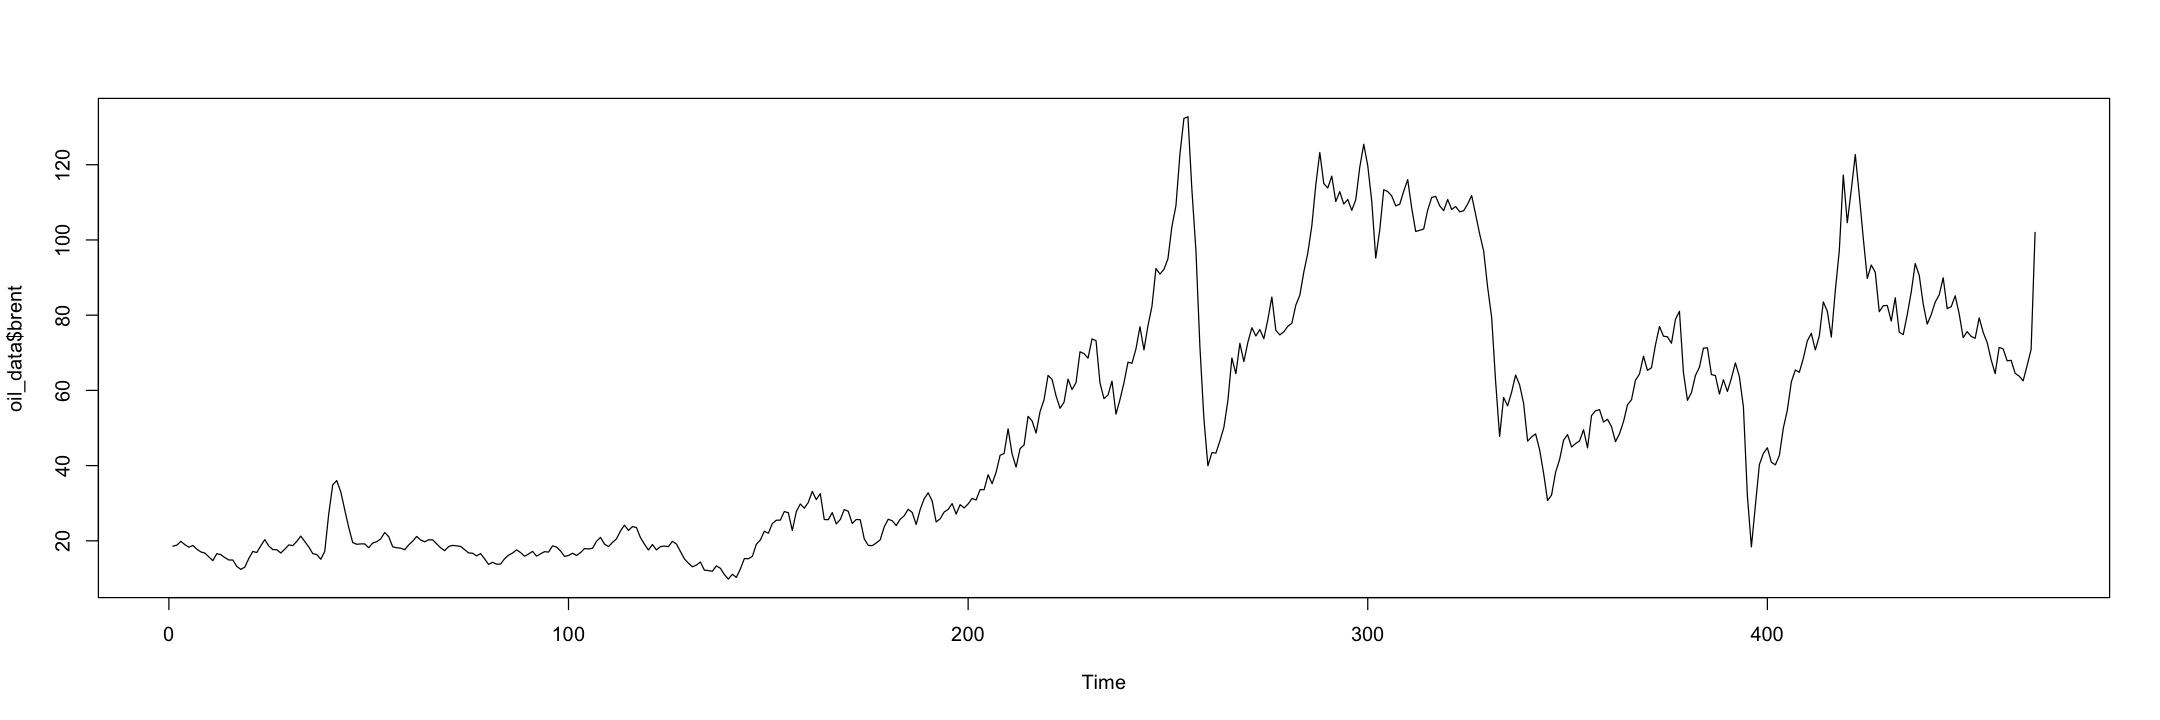

In [11]:
oil_data <- read.csv("brent.csv", stringsAsFactors = FALSE)

oil_data <- oil_data %>%
  mutate(
    date = as.Date(paste0("01-", Month), format = "%d-%b-%y"),
    brent = as.numeric(brent)
  ) %>%
  arrange(date)

range(oil_data$date)
par(mfrow = c(1, 1))
plot.ts(oil_data$brent)

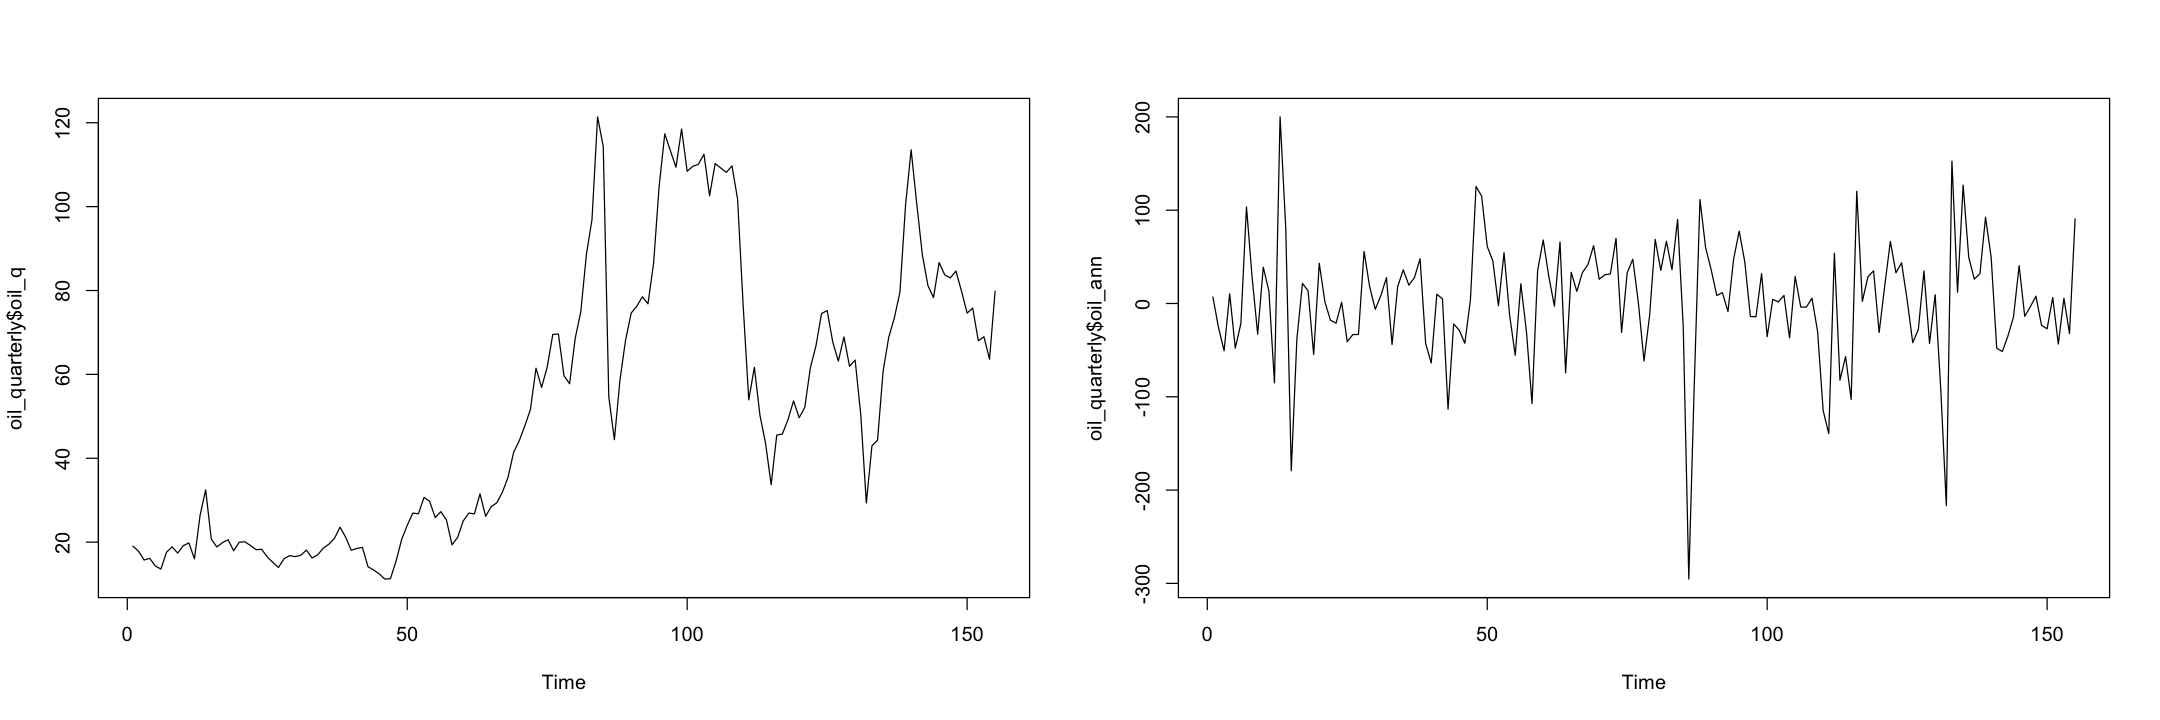

In [12]:
oil_quarterly <- oil_data %>%
  group_by(quarter = floor_date(date, "quarter")) %>%
  summarize(
    oil_q = mean(brent, na.rm = TRUE)
  ) %>% 
  arrange(quarter) %>%
  mutate(
    log_oil = log(oil_q),
    oil_ann = 400 * (log_oil - lag(log_oil, 1))
  ) %>%
  na.omit()


par(mfrow = c(1, 2))
plot.ts(oil_quarterly$oil_q)
plot.ts(oil_quarterly$oil_ann)

The data are transformed into annualized quarter-on-quarter first differences

## SHADOW RATE
[Shadow rate from  from Cynthia Wu's website](https://sites.google.com/view/jingcynthiawu/shadow-rates)

[Eonia rate](https://data.ecb.europa.eu/data/datasets/FM/FM.M.U2.EUR.4F.MM.EONIA.HSTA)

[Short-term rate](https://data.ecb.europa.eu/data/datasets/FM/FM.M.U2.EUR.4F.MM.UONSTR.HSTA)

[time]: 'date' [value]: 'rate' 



[1] "1994-01-01" "2026-04-01"

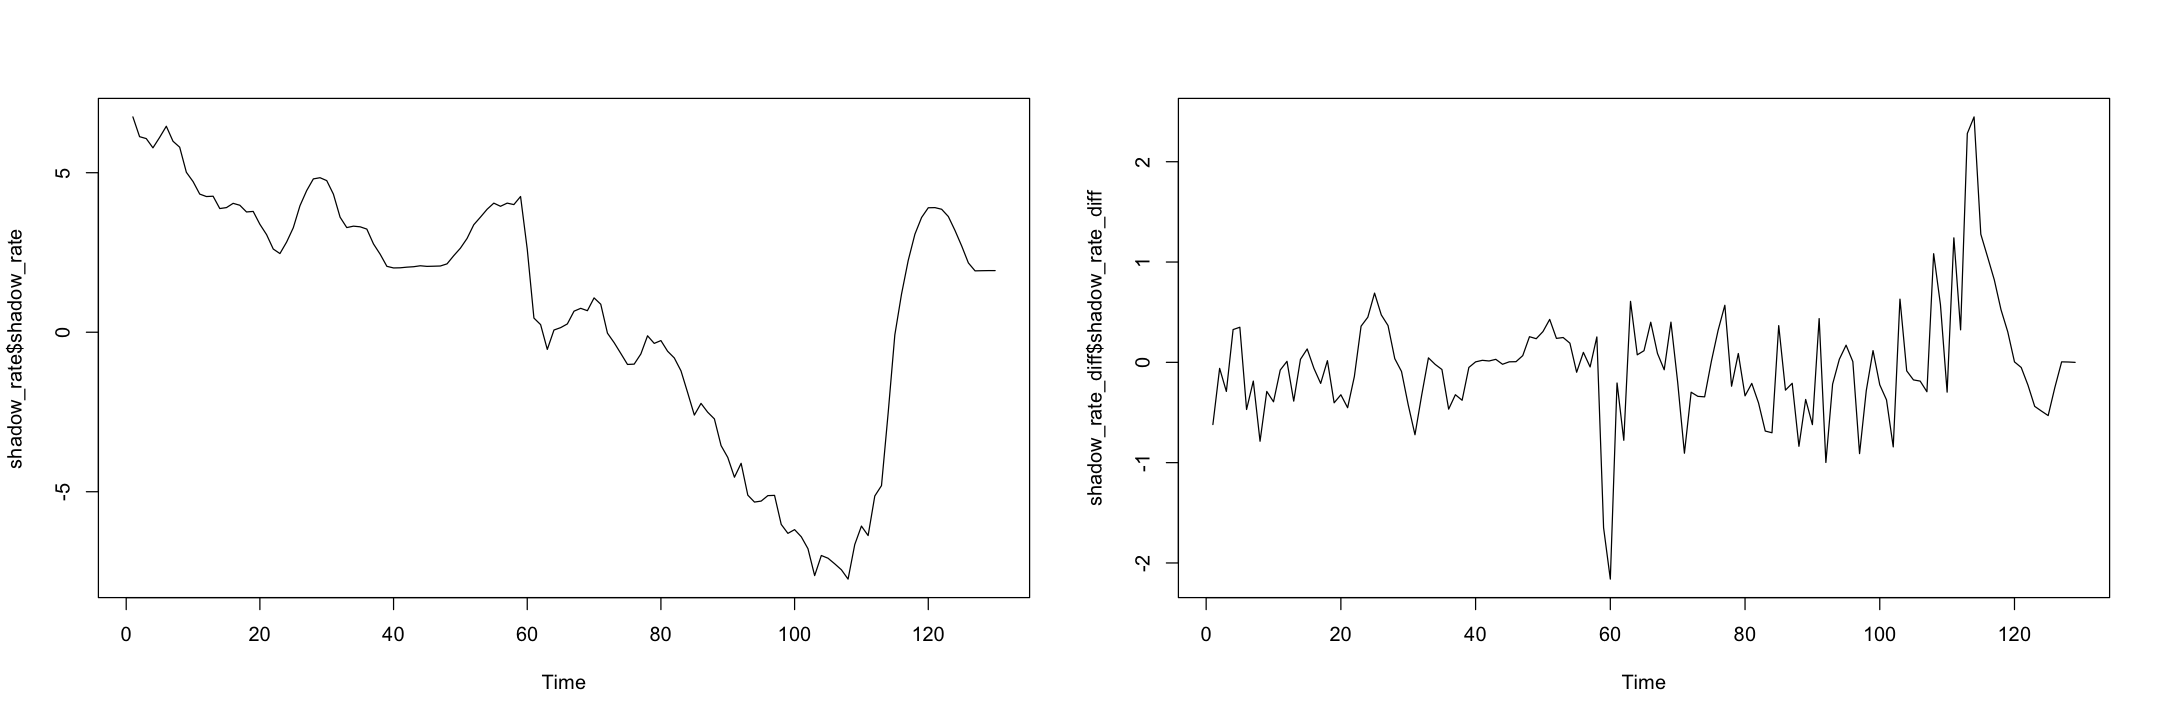

In [13]:
eonia_data <- get_data("FM.M.U2.EUR.4F.MM.EONIA.HSTA") %>%
  dplyr::mutate(date = as.Date(paste0(obstime, "-01"))) %>%
  dplyr::select(date, rate = obsvalue) %>%
  dplyr::arrange(date)

str_data <- get_data("FM.M.U2.EUR.4F.MM.UONSTR.HSTA") %>%
  dplyr::mutate(date = as.Date(paste0(obstime, "-01"))) %>%
  dplyr::select(date, rate = obsvalue) %>%
  dplyr::arrange(date)

combined_actual_rate <- bind_rows(
    eonia_data %>% filter(date < "2019-10-01"),
    str_data %>% filter(date >= "2019-10-01")
  ) %>%
  arrange(date)

quarterly_rate <- combined_actual_rate %>%
  group_by(date = floor_date(date, "quarter")) %>%
  summarize(rate = mean(rate, na.rm = TRUE)) %>%
  arrange(date)

shadow_values <- c(
  2.605, # 2008 Q4
  0.444, 0.238, -0.539, 0.069, # 2009
  0.144, 0.260, 0.660, 0.749,  # 2010
  0.675, 1.076, 0.877, -0.029, # 2011
  -0.327, -0.666, -1.010, -1.000, # 2012
  -0.681, -0.112, -0.350, -0.262, # 2013
  -0.596, -0.806, -1.210, -1.895, # 2014
  -2.597, -2.231, -2.508, -2.717, # 2015
  -3.554, -3.924, -4.545, -4.109, # 2016
  -5.107, -5.324, -5.293, -5.122, # 2017
  -5.114, -6.024, -6.305, -6.188, # 2018
  -6.412, -6.786, -7.629, -6.999, # 2019
  -7.084, -7.259, -7.446, -7.739, # 2020
  -6.656, -6.077, -6.374, -5.133, # 2021
  -4.809, -2.527  # 2022 (to Q2)
)
data_shadow_zlb <- ts(shadow_values, start = c(2008, 4), frequency = 4)
data_shadow_zlb <- ts_xts(data_shadow_zlb)

quarterly_xts <- ts_xts(quarterly_rate)
data_pre2012  <- quarterly_xts["/2008-09"]
data_post2022 <- quarterly_xts["2022-07/"]

shadowrate_final <- rbind(data_pre2012, data_shadow_zlb, data_post2022)

shadow_rate <- ts_df(shadowrate_final) %>% 
  rename(date = time, shadow_rate = value)

shadow_rate_diff <- shadow_rate %>%
  mutate(
    shadow_rate_diff = shadow_rate - lag(shadow_rate),
  ) %>%
  na.omit()

range(shadow_rate$date)
par(mfrow = c(1, 2))
plot.ts(shadow_rate$shadow_rate)
plot.ts(shadow_rate_diff$shadow_rate_diff)

In [72]:
adf.test(shadow_rate$shadow_rate)


	Augmented Dickey-Fuller Test

data:  shadow_rate$shadow_rate
Dickey-Fuller = -2.4634, Lag order = 5, p-value = 0.3839
alternative hypothesis: stationary


As data for the monetary shock, the Eonia rate is used until 2008Q3, then for the period of low interest rates and the ZLB, the values are imputed as the Shadow rate from Cynthia Wu's website until 2022Q2. After the period of Great Inflation arrived, data from the overnight short-term rate are used.

Although the ADF test indicates that the interest rate is non-stationary in levels, I will use the data in levels. Differencing the interest rate would result in a significant loss of long-run information. Furthermore, interest rates do not have a deterministic trend and are theoretically bounded

## Real Gross Domestic Product for Germany 
(NGDPRSAXDCDEQ)

Source: FRED / IMF

Units: Millions of Domestic Currency,
Seasonally Adjusted

Frequency: Quarterly

[1] "1991-01-01" "2025-10-01"

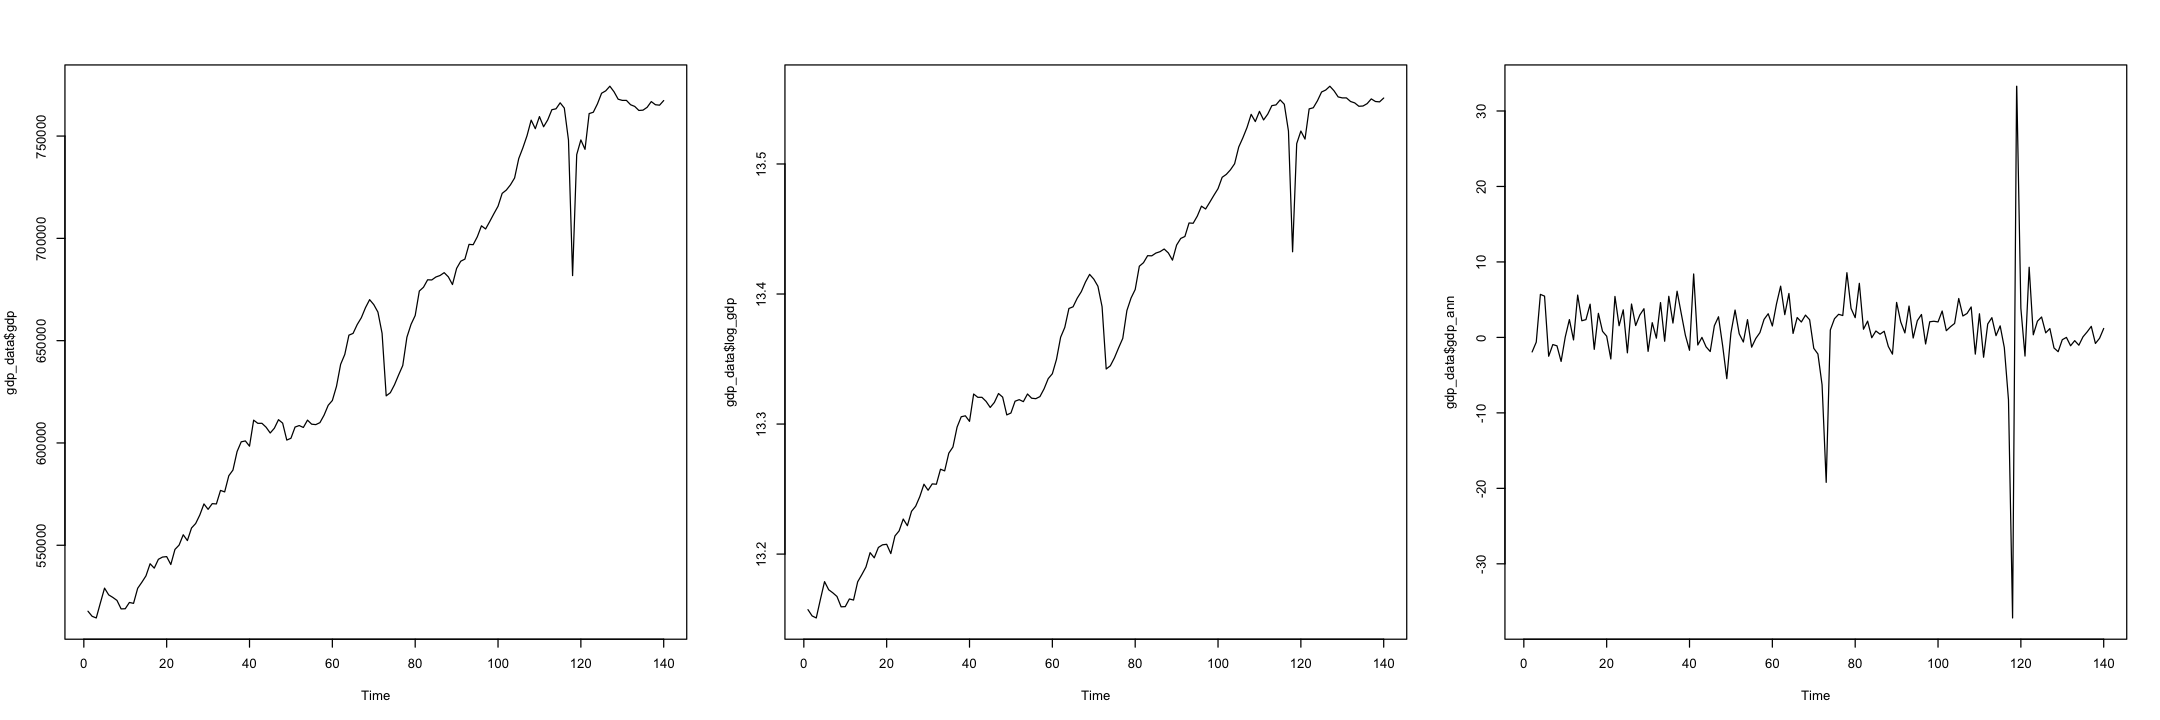

In [14]:
fredr_set_key(fred_key)
gdp_data <- fredr(
    series_id = "NGDPRSAXDCDEQ",
    observation_start = as.Date("1991-01-01"),
    frequency = "q"
) %>%
  dplyr::select(date, gdp = value) %>%
  dplyr::arrange(date)

range(gdp_data$date)

par(mfrow = c(1, 3))
plot.ts(gdp_data$gdp)

gdp_data <- gdp_data %>% 
  mutate(log_gdp = log(gdp),
         gdp_ann = 400 * (log_gdp - lag(log_gdp, 1))
         )
plot.ts(gdp_data$log_gdp)
plot.ts(gdp_data$gdp_ann)

The data are transformed into annualized quarter-on-quarter first differences

## HICP Inflation rate 
(HICP.M.DE.N.000000.4D0.INX)
Source: ECB Data Portal / Eurostat

Units:  Index,
Not Seasonally Adjusted

Frequency: Monthly

[1] "1996-01-01" "2026-04-01"

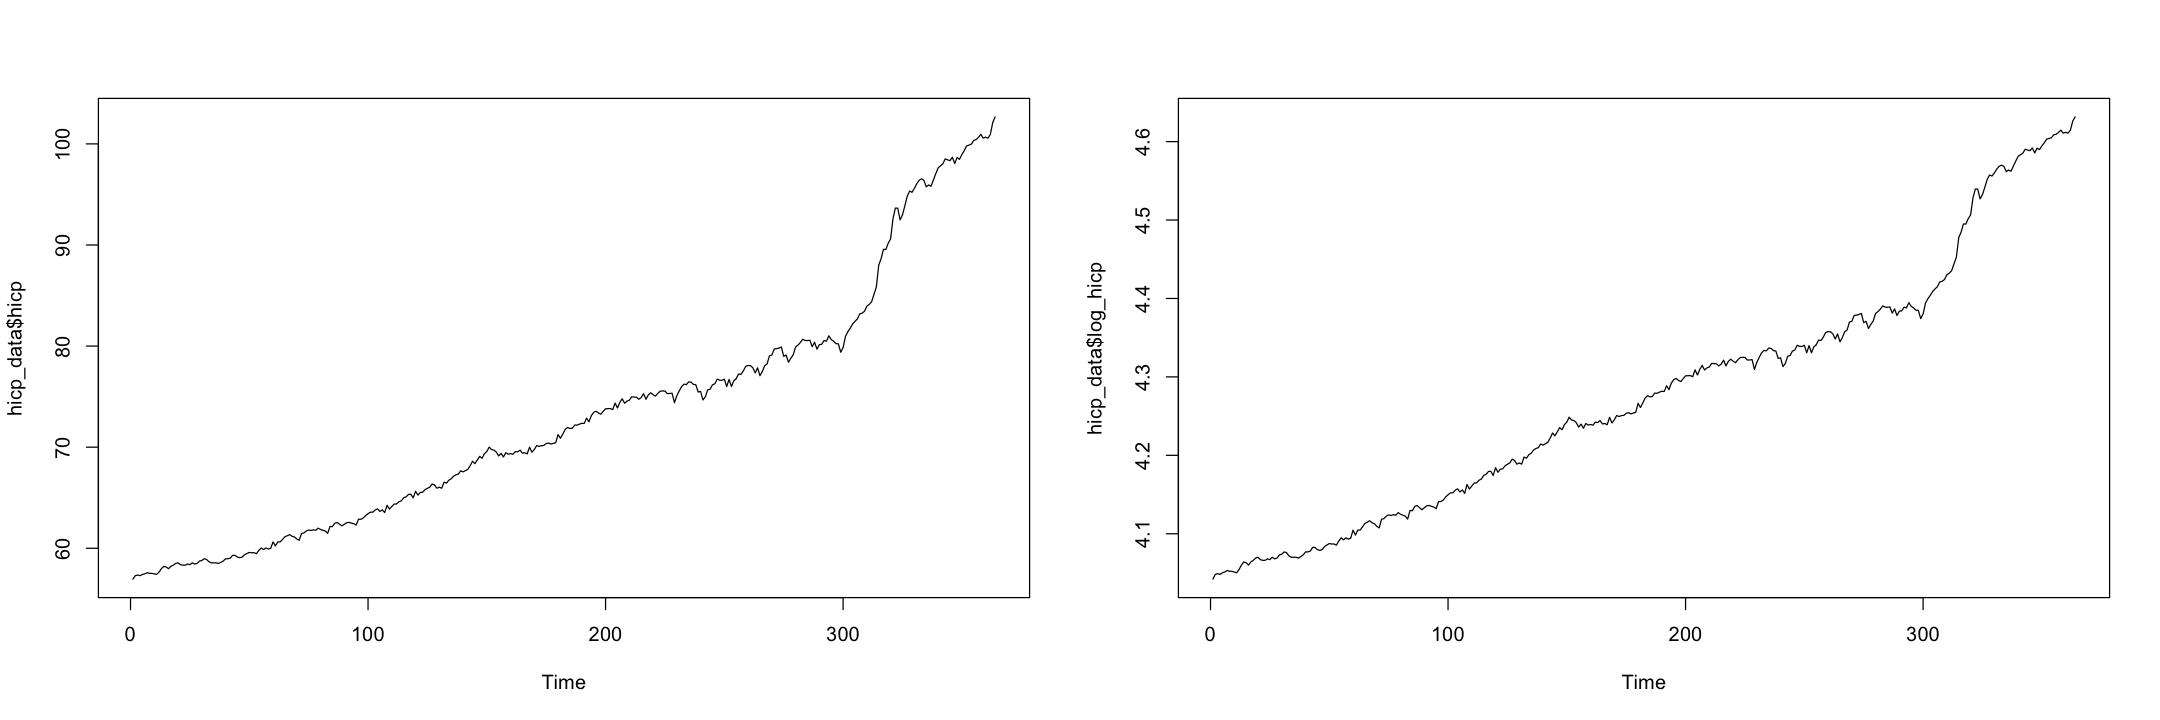

In [15]:
hicp_data <- get_data("HICP.M.DE.N.000000.4D0.INX") %>%
  dplyr::mutate(date = as.Date(paste0(obstime, "-01"))) %>%
  dplyr::select(date, hicp = obsvalue) %>%
  dplyr::arrange(date)

range(hicp_data$date)
par(mfrow = c(1, 2))

hicp_data <- hicp_data %>% 
  mutate(log_hicp = log(hicp))


plot.ts(hicp_data$hicp)
plot.ts(hicp_data$log_hicp)

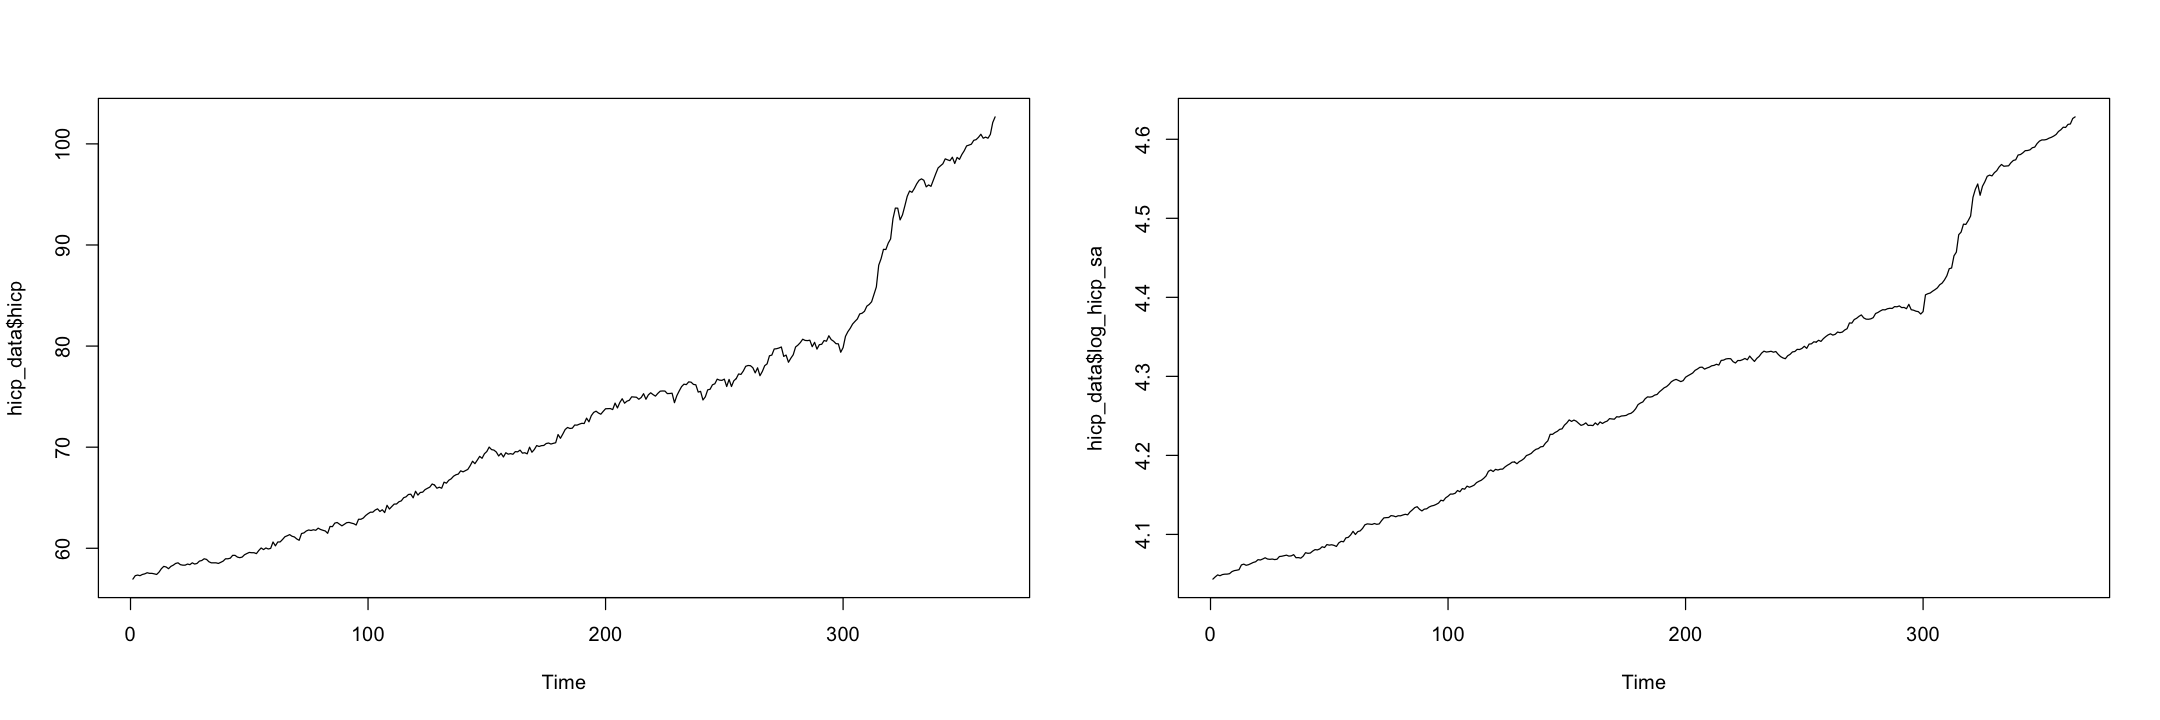

In [16]:
# seasonallity adjustment
log_hicp_ts <- ts(hicp_data$log_hicp, start = c(1996, 1), frequency = 12)
tramo_m_model <- tramoseats(log_hicp_ts, spec = "RSAfull")
hicp_data$log_hicp_sa <- as.numeric(tramo_m_model$final$series[, "sa"])

#plots
par(mfrow = c(1, 2))
plot.ts(hicp_data$hicp)
plot.ts(hicp_data$log_hicp_sa)

#### 2.1 Transformation – HICP

[1] "1996-01-01" "2026-04-01"

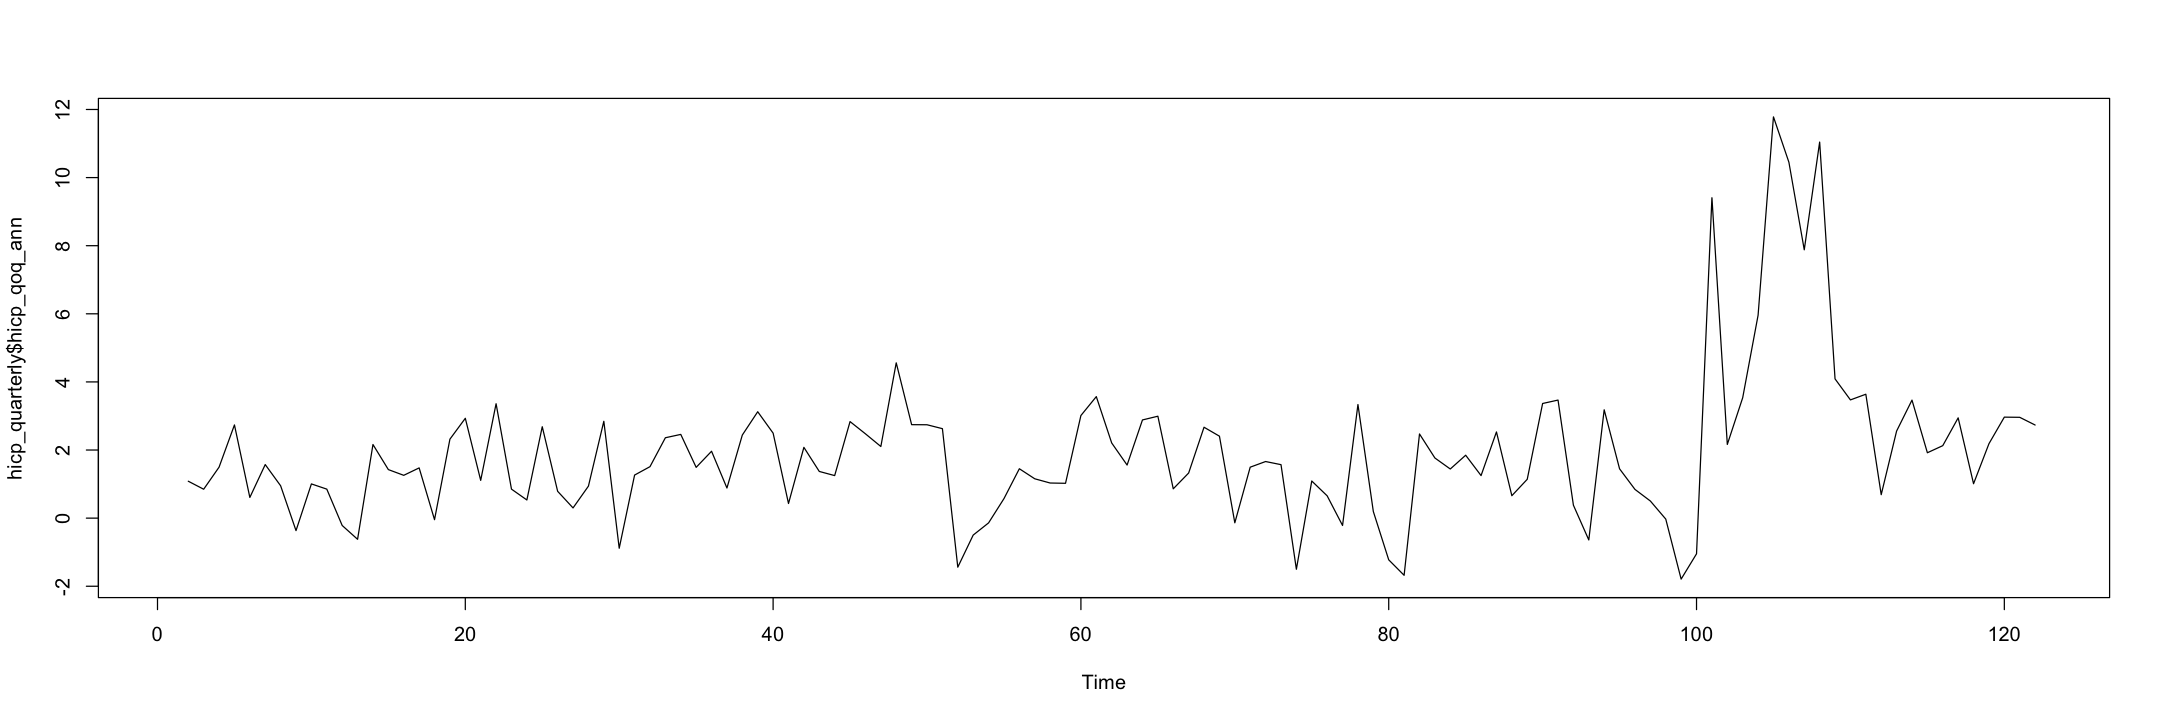

In [17]:
hicp_quarterly <- hicp_data %>%
  group_by(quarter = floor_date(date, "quarter")) %>%
  summarize(
    log_hicp_sa_q = mean(log_hicp_sa, na.rm = TRUE)
  ) %>%
  mutate(
    hicp_qoq_ann = 400*(log_hicp_sa_q - lag(log_hicp_sa_q, 1))
  )
range(hicp_quarterly$quarter)
par(mfrow = c(1,1))
plot.ts(hicp_quarterly$hicp_qoq_ann)

The data are transformed into annualized quarter-on-quarter first differences

# MERGE

In [18]:
data <- gdp_data %>%
  inner_join(oil_quarterly %>% rename(date = quarter), by = "date") %>%
  inner_join(hicp_quarterly %>% rename(date = quarter), by = "date") %>%
  inner_join(shadow_rate, by = "date") %>%
  dplyr::select(
    date, 
    oil = oil_ann,
    gdp = gdp_ann, 
    hicp = hicp_qoq_ann, 
    rate = shadow_rate,
  ) %>%
  na.omit()

head(data,2)
tail(data,2)

date,oil,gdp,hicp,rate
<date>,<dbl>,<dbl>,<dbl>,<dbl>
1996-04-01,19.68701,5.427645,1.0838872,4.723333
1996-07-01,27.72930,1.544912,0.8488372,4.330000


date,oil,gdp,hicp,rate
<date>,<dbl>,<dbl>,<dbl>,<dbl>
2025-07-01,5.607023,-0.11466,2.184700,1.923617
2025-10-01,-32.236251,1.18338,2.965861,1.928417


In [74]:
adf_vysledky <- lapply(data[, -1], adf.test)
sapply(adf_vysledky, function(x) x$p.value)

Warning message in FUN(X[[i]], ...):
“p-value smaller than printed p-value”
Warning message in FUN(X[[i]], ...):
“p-value smaller than printed p-value”


oil        gdp       hicp       rate 
0.01000000 0.01000000 0.02560154 0.63841639

## VAR model just with oil shocks

First of all I tried to estimate VAR model only with oil price without monetary policy shocks. Just to see the variable make sense for me

In [19]:
vardata1 <- data[,c("oil", "gdp", "hicp")]

In [218]:
var1.select <- VARselect(vardata1, lag.max=8, type ="const")
var1.select$selection

AIC(n)  HQ(n)  SC(n) FPE(n) 
     3      1      1      3

Although some information criteria suggested 3 lags, I selected 4 lags to fully capture the annual macroeconomic dynamics

In [219]:
model1 <- VAR(vardata1, p = 4, type = "const")
test <- serial.test(model1, lags.pt = 12, type = "PT.asymptotic")
test$serial


	Portmanteau Test (asymptotic)

data:  Residuals of VAR object model1
Chi-squared = 81.395, df = 72, p-value = 0.21


In [220]:
summary(model1)


VAR Estimation Results:
Endogenous variables: oil, gdp, hicp 
Deterministic variables: const 
Sample size: 115 
Log Likelihood: -1172.068 
Roots of the characteristic polynomial:
0.7363 0.7355 0.7355 0.6542 0.6542 0.5596 0.501 0.501 0.4489 0.4489 0.2848 0.1687
Call:
VAR(y = vardata1, p = 4, type = "const")


Estimation results for equation oil: 
oil = oil.l1 + gdp.l1 + hicp.l1 + oil.l2 + gdp.l2 + hicp.l2 + oil.l3 + gdp.l3 + hicp.l3 + oil.l4 + gdp.l4 + hicp.l4 + const 

        Estimate Std. Error t value Pr(>|t|)  
oil.l1   0.33589    0.13184   2.548   0.0123 *
gdp.l1  -1.83735    1.25639  -1.462   0.1467  
hicp.l1 -3.17668    4.48930  -0.708   0.4808  
oil.l2  -0.17037    0.13790  -1.236   0.2195  
gdp.l2   1.31374    1.34833   0.974   0.3322  
hicp.l2  1.82597    4.91194   0.372   0.7109  
oil.l3   0.05614    0.13731   0.409   0.6835  
gdp.l3  -1.82989    1.38961  -1.317   0.1908  
hicp.l3 -0.93684    4.48890  -0.209   0.8351  
oil.l4   0.06254    0.12400   0.504   0.6151  
gdp.l4  

For the oil prices eq. we do not have a good fit. This makes sense because oil is an exogenous variable that is not influenced by German inflation or GDP.

The GDP equation has a low R-squared. It depends negatively on its own lagged value, which indicates a mean reversion. Interestingly, it depends positively on past oil prices, even though intuition would suggest the opposite.

The inflation equation has the best fit at 50.23%. We can see that inflation is highly persistent. At the same time, GDP acts as a demand shock and has a positive effect on inflation.

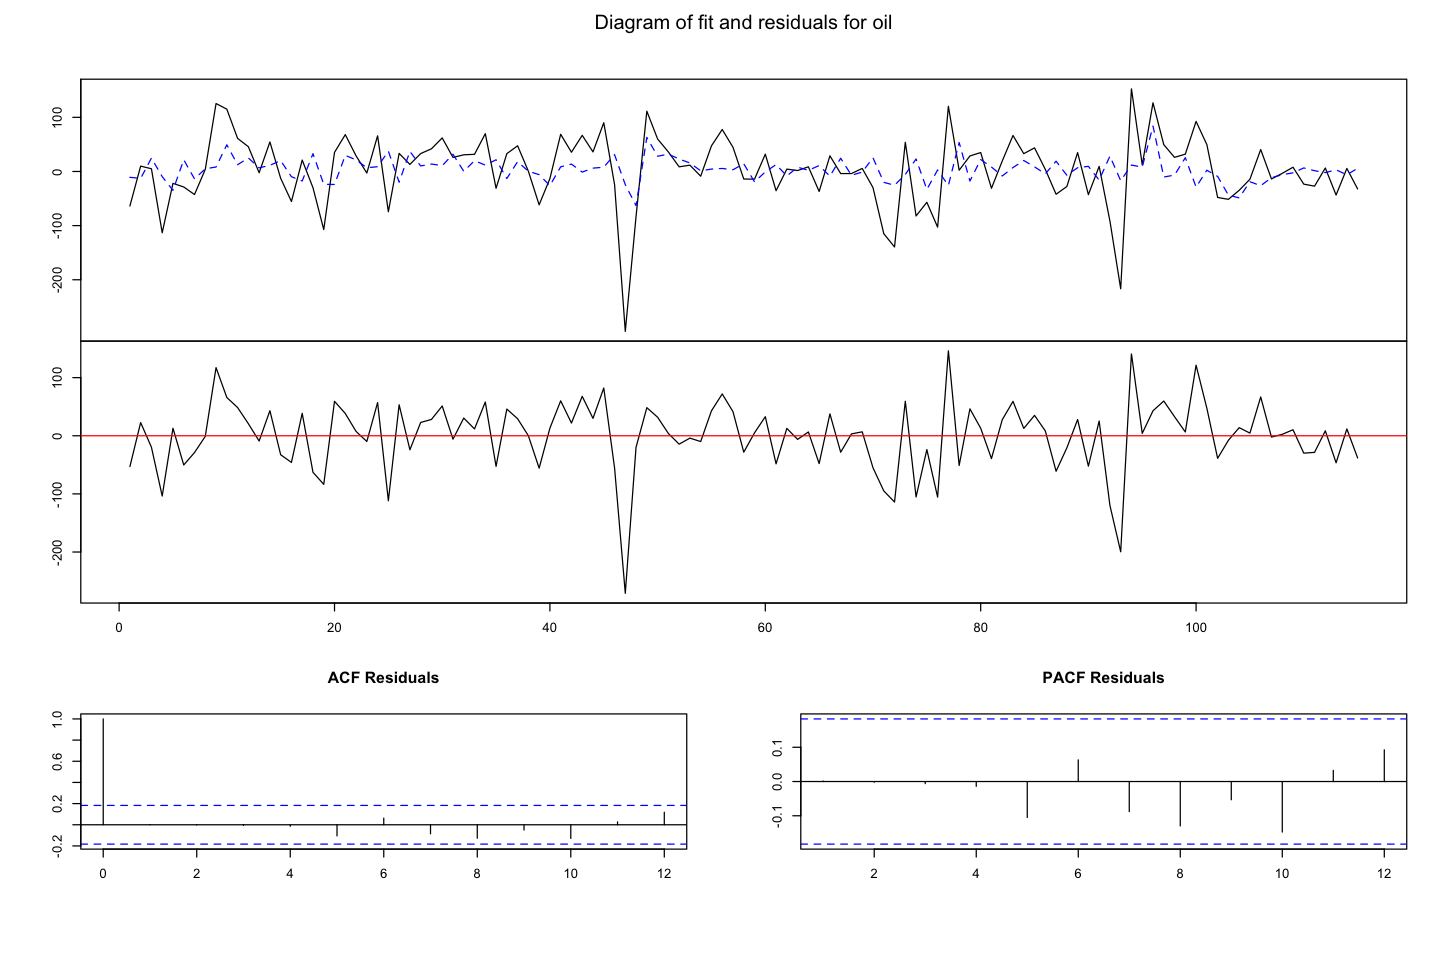

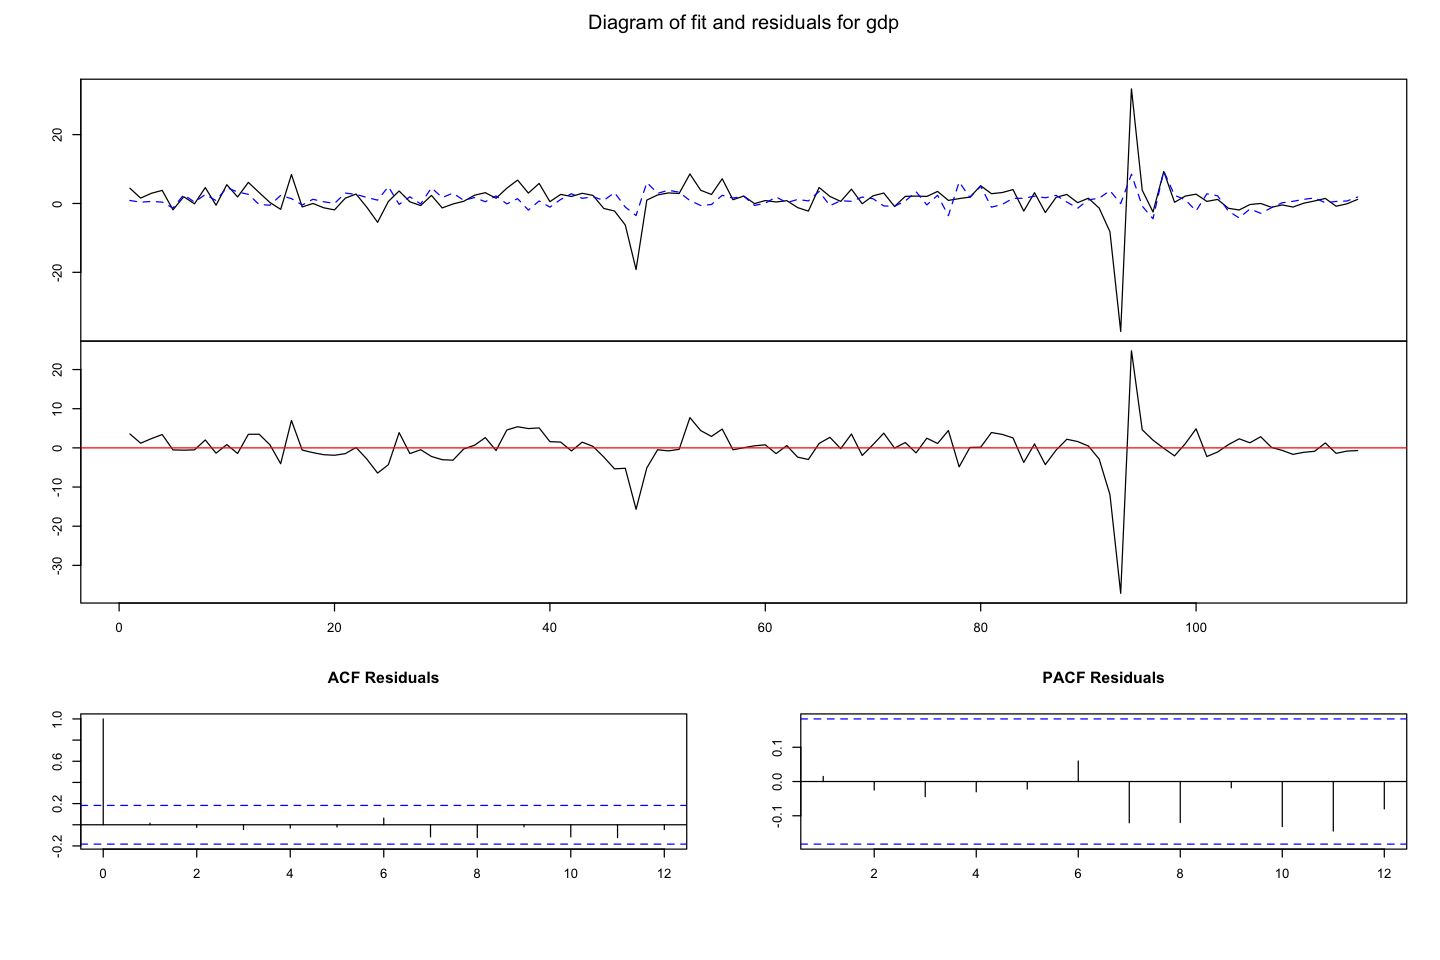

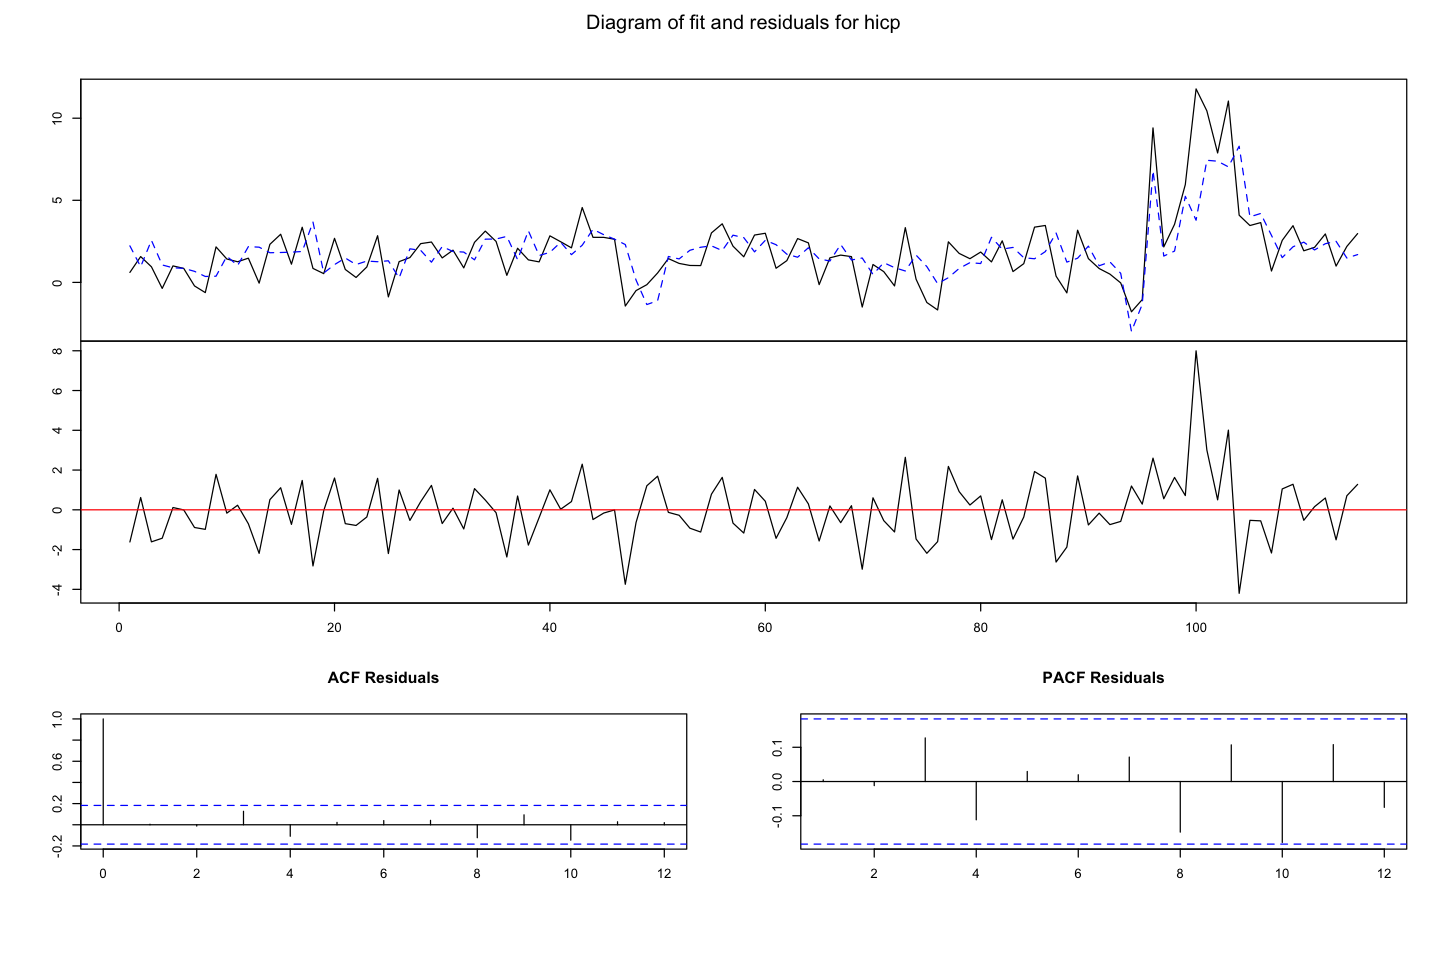

In [221]:
options(repr.plot.width = 12, repr.plot.height = 8)
plot(model1)

## VAR model, monetary policy shocks included

In [20]:
vardata2 <- data[,c("oil","gdp", "hicp", "rate")]

In [21]:
var2.select <- VARselect(vardata2, lag.max=12, type ="const")
var2.select$selection

AIC(n)  HQ(n)  SC(n) FPE(n) 
     2      2      1      2

In [22]:
model2 <- VAR(vardata2, p = 2, type = "const")
test <- serial.test(model2)
test$serial


	Portmanteau Test (asymptotic)

data:  Residuals of VAR object model2
Chi-squared = 237.57, df = 224, p-value = 0.2546


In [23]:
summary(model2)


VAR Estimation Results:
Endogenous variables: oil, gdp, hicp, rate 
Deterministic variables: const 
Sample size: 117 
Log Likelihood: -1252.724 
Roots of the characteristic polynomial:
0.9259 0.7559 0.491 0.491 0.3323 0.3323 0.3235 0.3235
Call:
VAR(y = vardata2, p = 2, type = "const")


Estimation results for equation oil: 
oil = oil.l1 + gdp.l1 + hicp.l1 + rate.l1 + oil.l2 + gdp.l2 + hicp.l2 + rate.l2 + const 

        Estimate Std. Error t value Pr(>|t|)   
oil.l1    0.3667     0.1273   2.880  0.00479 **
gdp.l1   -1.7112     1.2340  -1.387  0.16839   
hicp.l1  -5.3547     3.9541  -1.354  0.17849   
rate.l1  -7.8066    13.7988  -0.566  0.57274   
oil.l2   -0.1446     0.1199  -1.206  0.23047   
gdp.l2    1.8489     1.2663   1.460  0.14717   
hicp.l2   2.0709     4.1348   0.501  0.61750   
rate.l2   6.7282    13.7968   0.488  0.62678   
const     9.0783    10.3351   0.878  0.38168   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Residual standard error: 62.84 on 

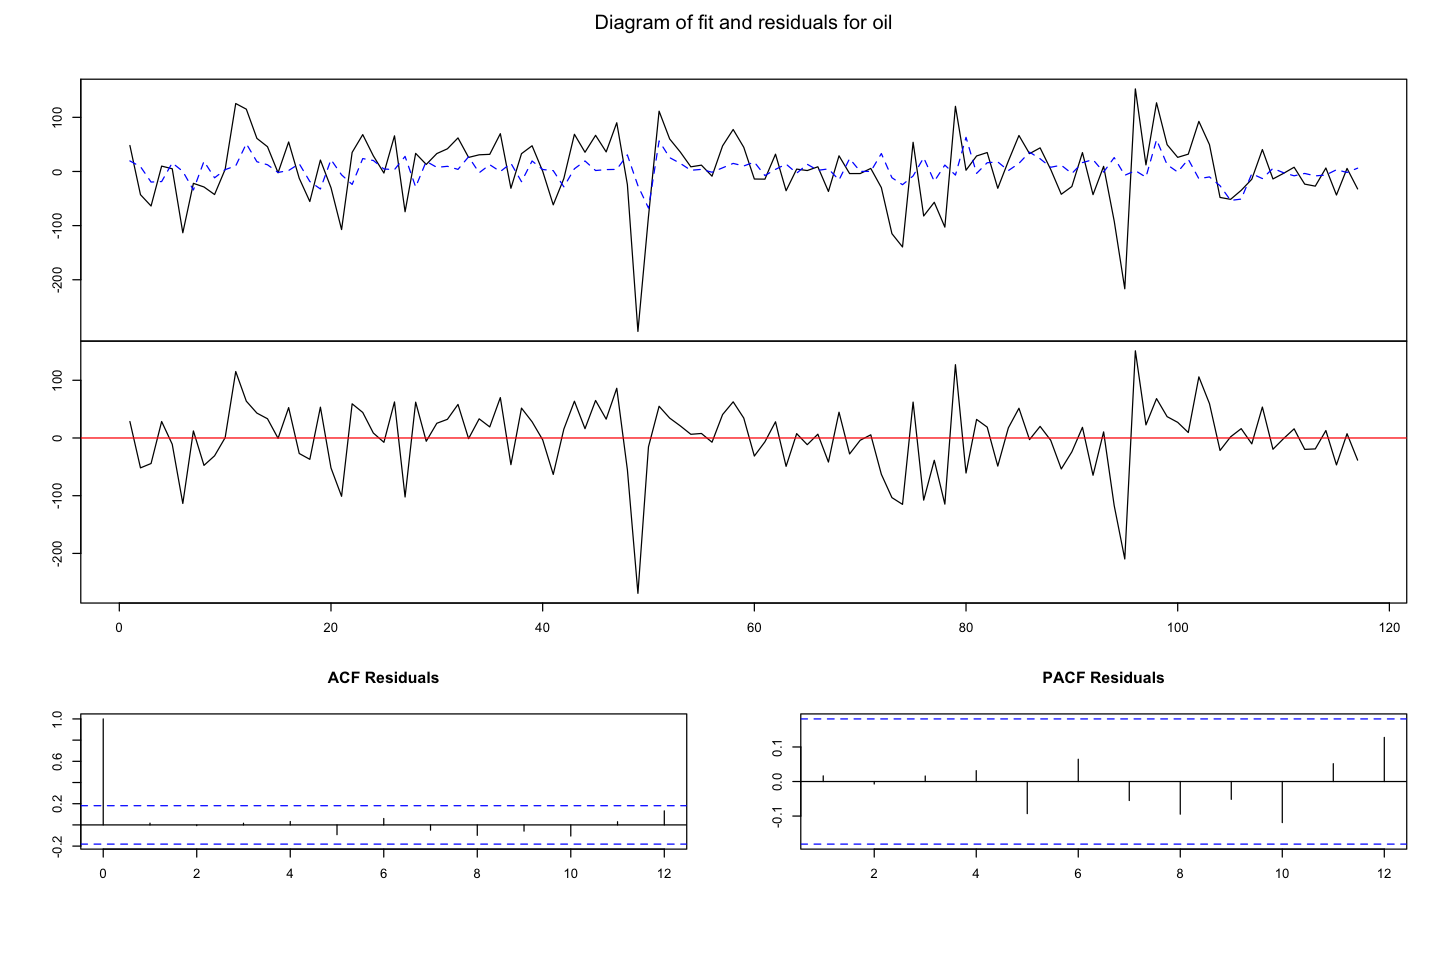

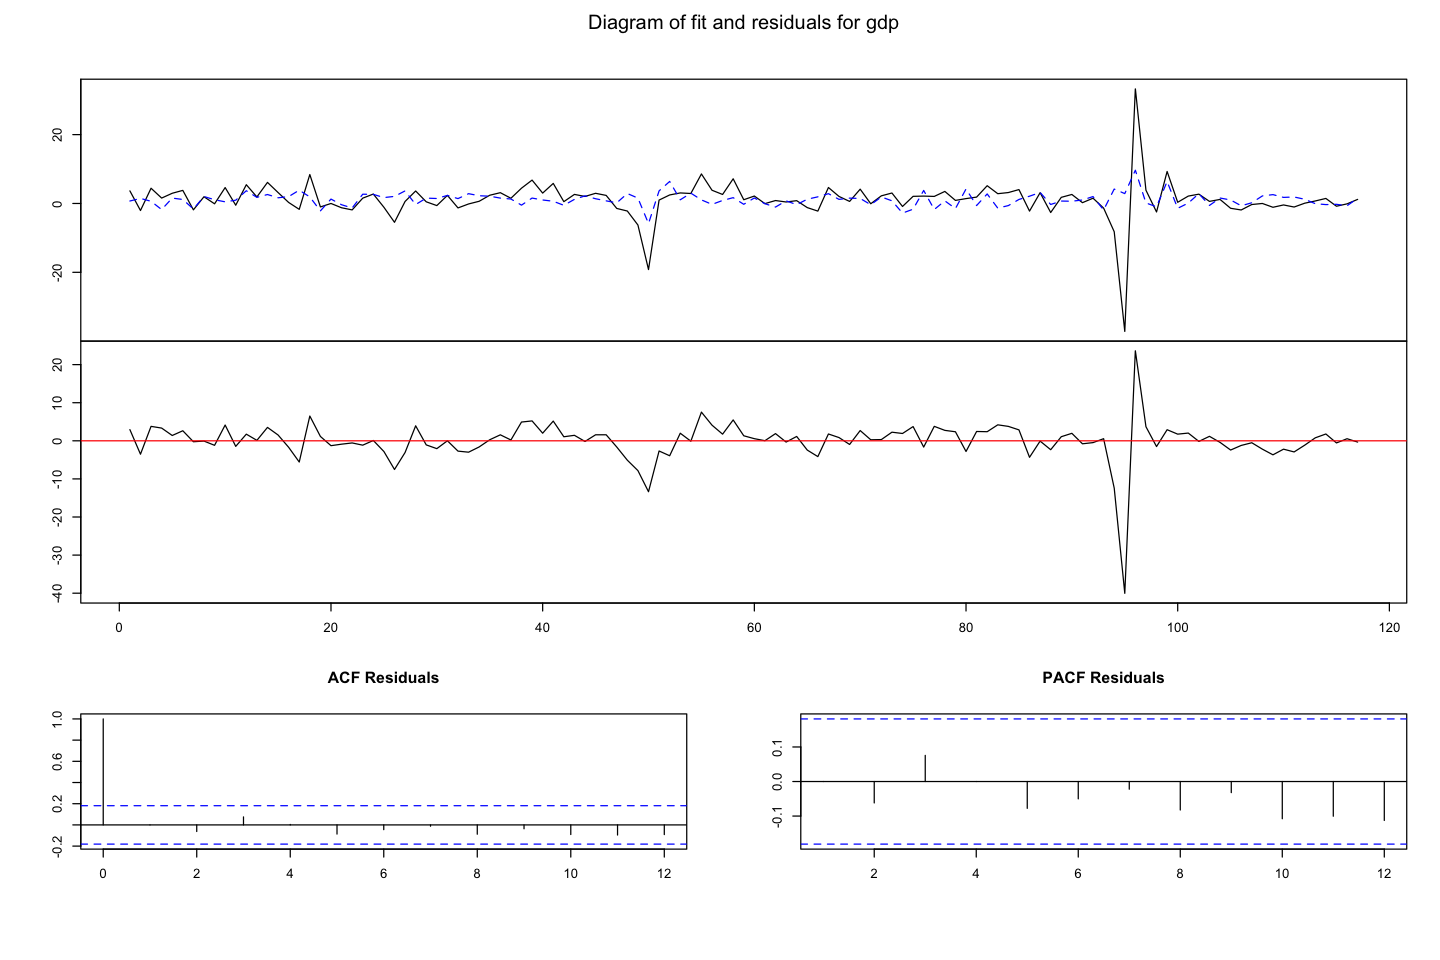

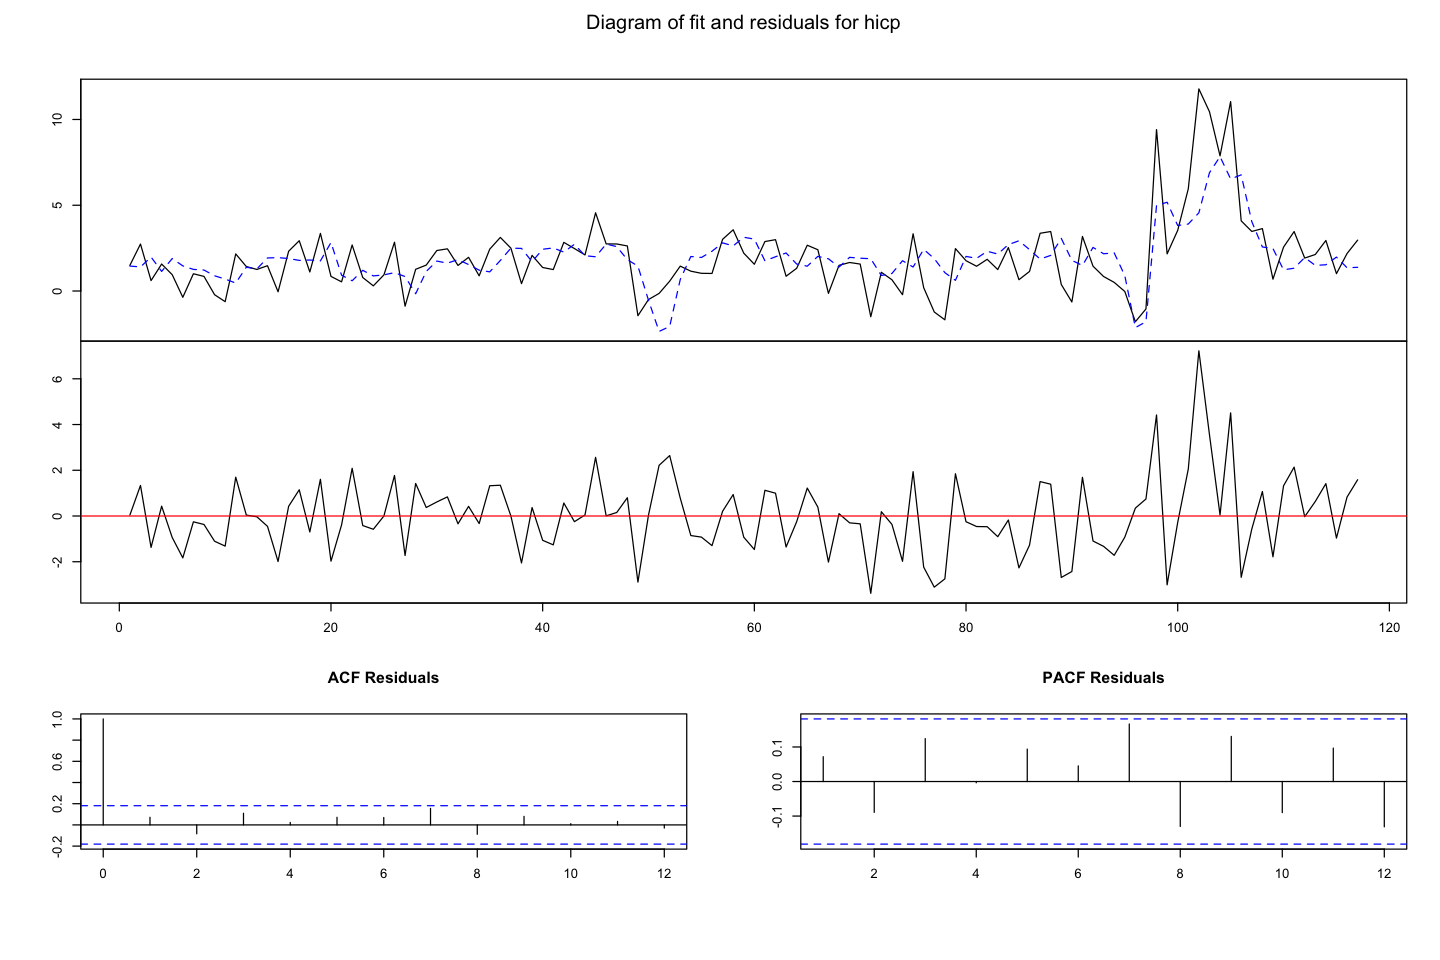

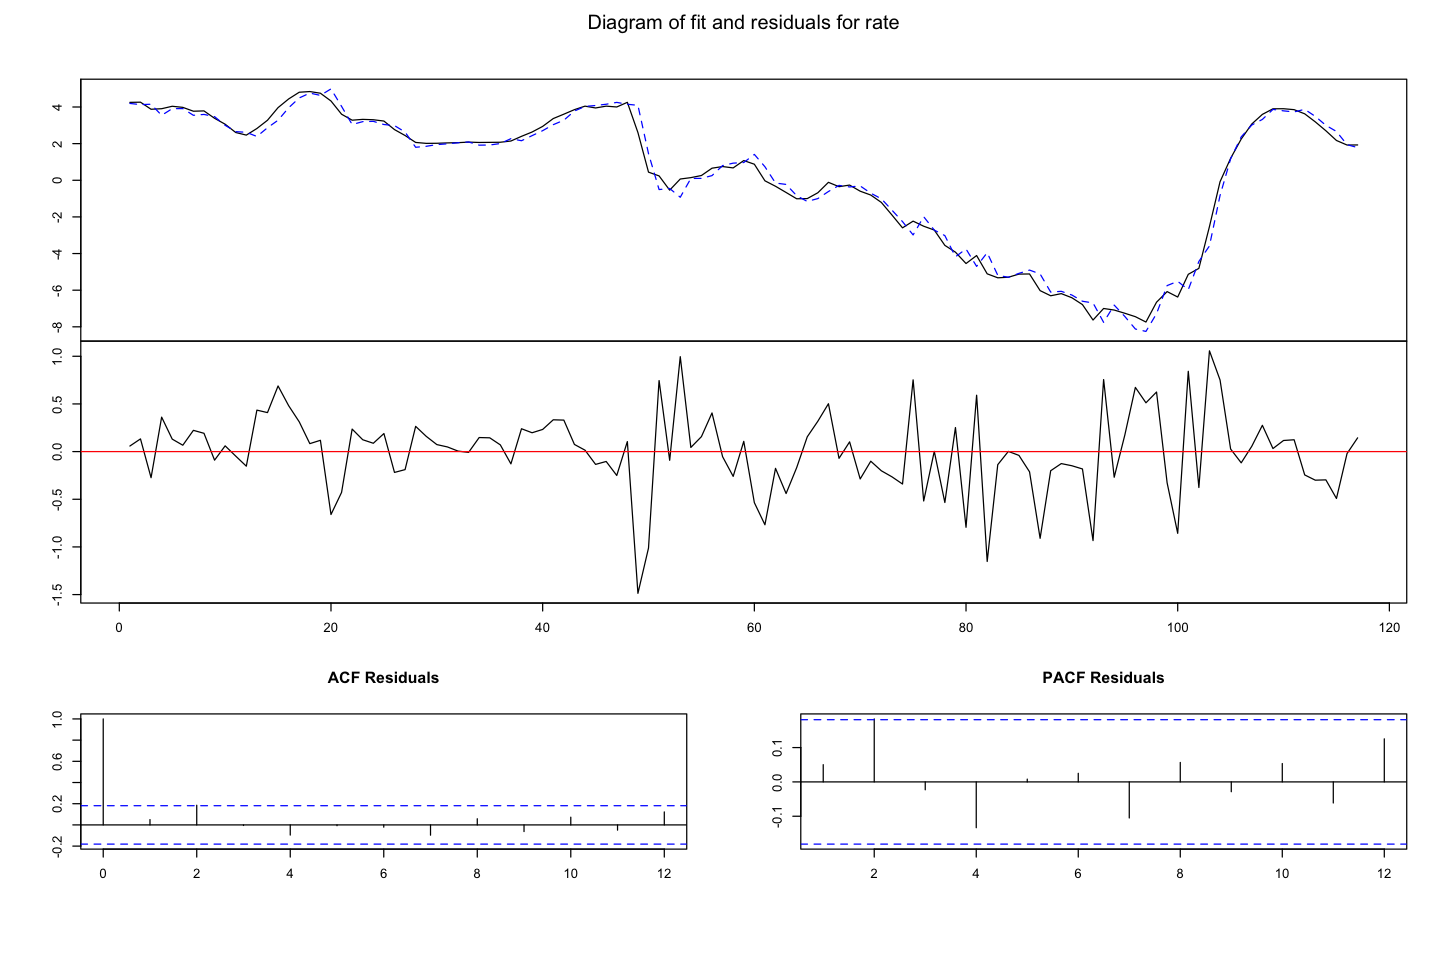

In [24]:
options(repr.plot.width = 12, repr.plot.height = 8)
plot(model2)

## Forecast

In [25]:
predict(model2, n.ahead = 12, ci = 0.95)

$oil
            fcst     lower    upper       CI
 [1,] -19.259272 -142.4209 103.9024 123.1616
 [2,]   1.644291 -125.6745 128.9631 127.3188
 [3,]   2.976611 -125.7961 131.7493 128.7727
 [4,]   1.518550 -127.8176 130.8547 129.3361
 [5,]   2.977640 -126.7879 132.7431 129.7655
 [6,]   3.054408 -126.8087 132.9175 129.8631
 [7,]   3.223611 -126.6999 133.1472 129.9235
 [8,]   3.501091 -126.4508 133.4530 129.9519
 [9,]   3.568818 -126.3932 133.5308 129.9620
[10,]   3.661103 -126.3059 133.6281 129.9670
[11,]   3.721110 -126.2474 133.6897 129.9685
[12,]   3.743586 -126.2253 133.7125 129.9689

$gdp
            fcst     lower    upper       CI
 [1,] 0.09797034 -10.83818 11.03412 10.93615
 [2,] 0.49811125 -11.00507 12.00130 11.50318
 [3,] 1.35810528 -10.20639 12.92260 11.56450
 [4,] 1.03438407 -10.55716 12.62593 11.59154
 [5,] 1.05445335 -10.55686 12.66576 11.61131
 [6,] 1.11279690 -10.50127 12.72687 11.61407
 [7,] 1.08246648 -10.53194 12.69687 11.61441
 [8,] 1.10271699 -10.51258 12.71801 11.61529

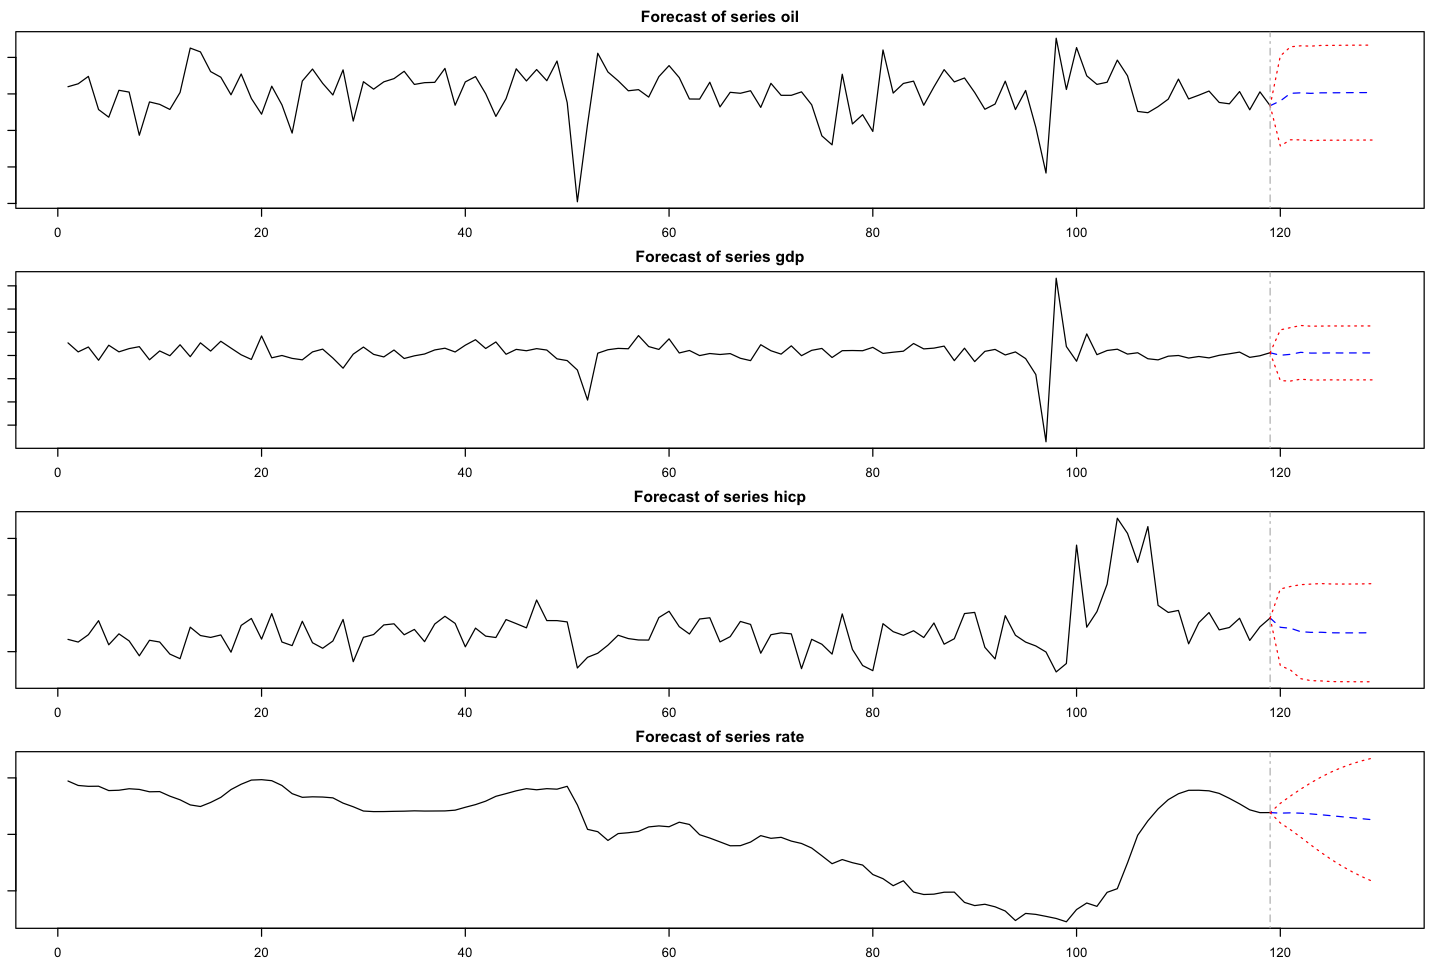

In [196]:
par(mar = c(2, 1, 2, 1))
plot(predict(model2))

# IRF

based on ordering, each variables influences contemporaneously only those ordered after it.

1) Oil price – exogenous
2) GDP – react faster than inflation
3) HICP – nominal rigidity
4) Shadow rate – endogenous (ECB reacts to other variables)

In [26]:
head(vardata2)

oil,gdp,hicp,rate
<dbl>,<dbl>,<dbl>,<dbl>
19.687013,5.427645,1.0838872,4.723333
27.729298,1.544912,0.8488372,4.330000
47.969859,3.652018,1.4968745,4.253333
-42.836302,-2.046744,2.7370248,4.263333
-63.764875,4.424007,0.6075671,3.876667
9.920275,1.568195,1.5726235,3.906667


### IRF for oil shock

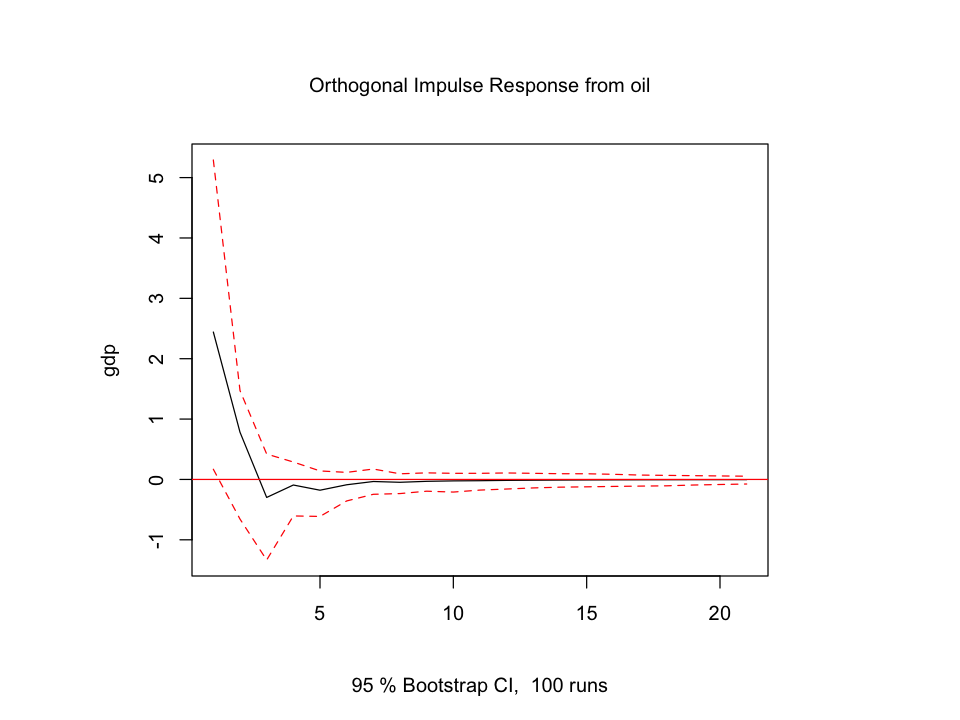

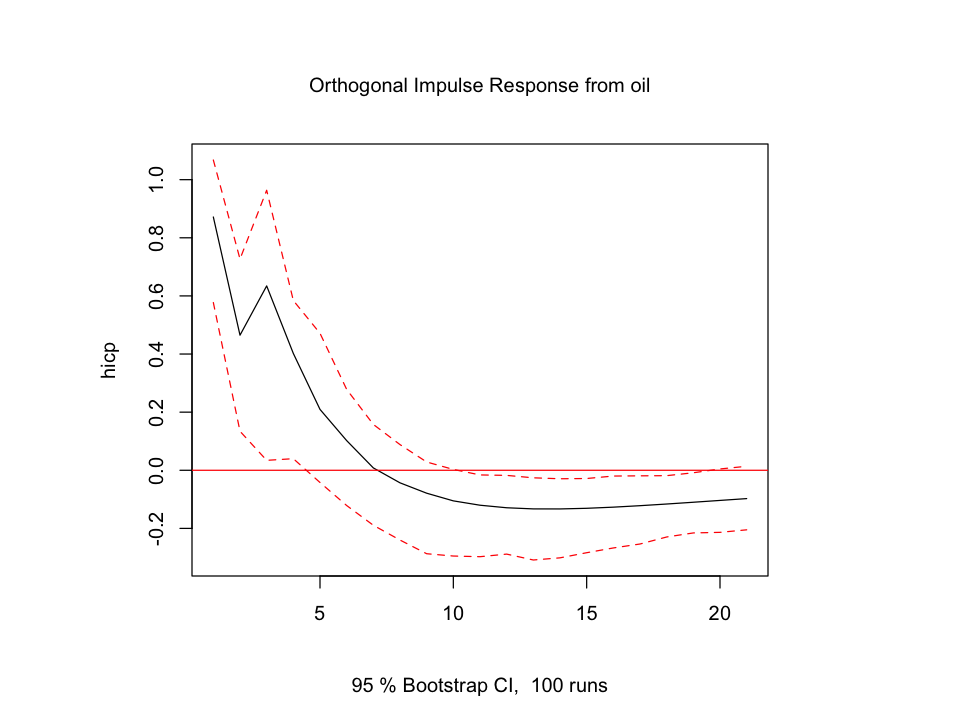

In [27]:
options(repr.plot.width = 8, repr.plot.height = 6)
plot(irf(model2,impulse = "oil", response = "gdp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))
plot(irf(model2,impulse = "oil", response = "hicp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))

### IRF for interest rate shock

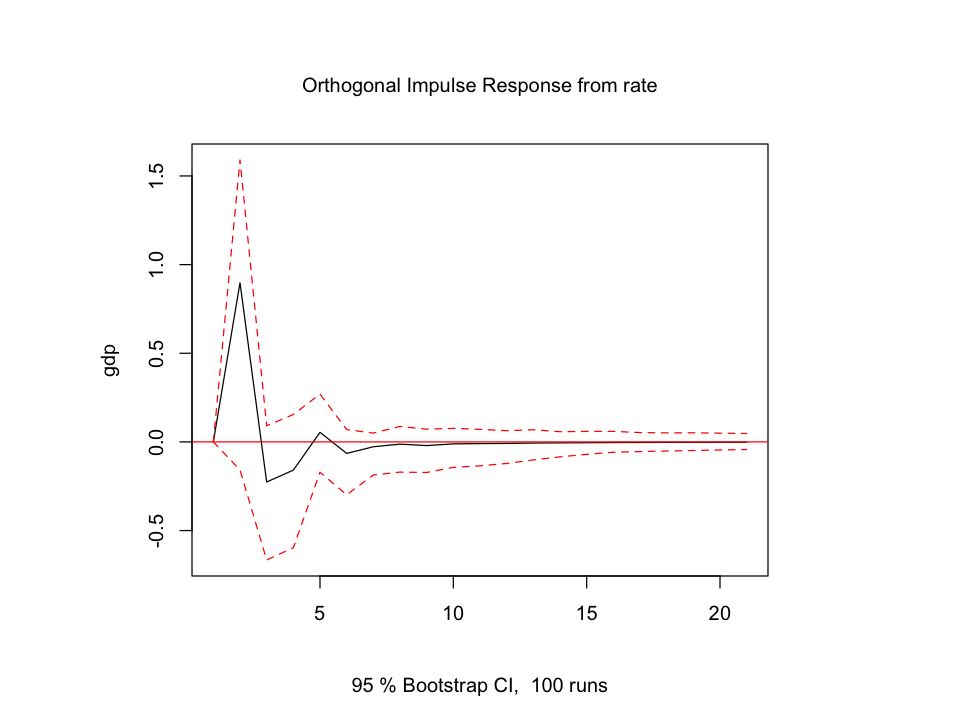

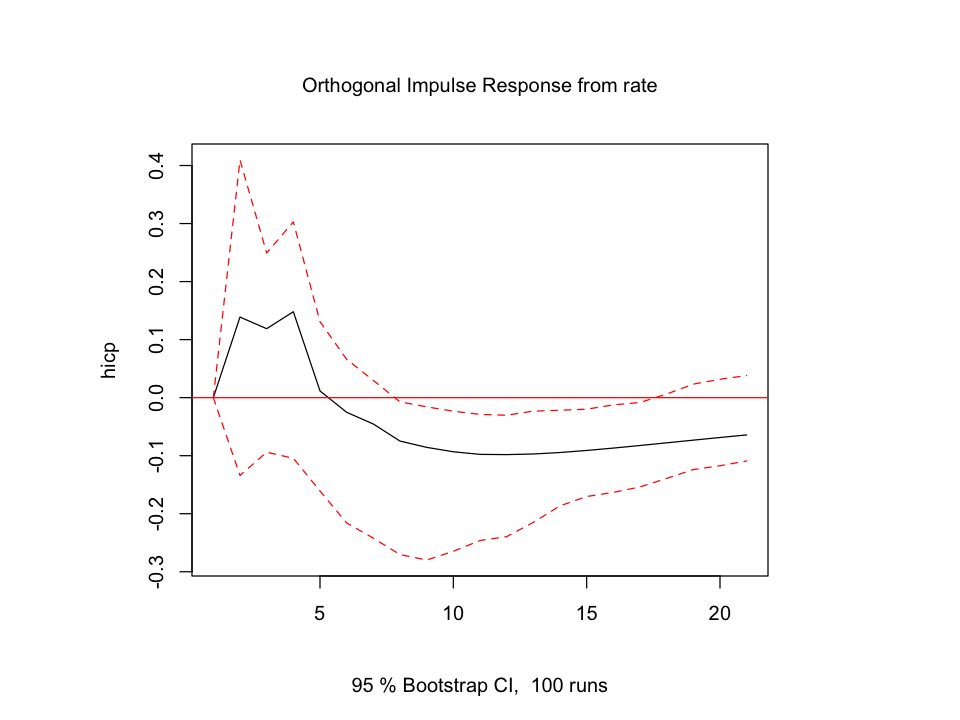

In [28]:
options(repr.plot.width = 8, repr.plot.height = 6)
plot(irf(model2,impulse = "rate", response = "gdp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))
plot(irf(model2,impulse = "rate", response = "hicp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))

we have a price puzzle and no effect of monetary policy, therefore i will try to use more lags

## IRF with 4 lags

In [208]:
model3 <- VAR(vardata2, p = 4, type = "const")
test <- serial.test(model3)
test$serial


	Portmanteau Test (asymptotic)

data:  Residuals of VAR object model3
Chi-squared = 214.79, df = 192, p-value = 0.1243


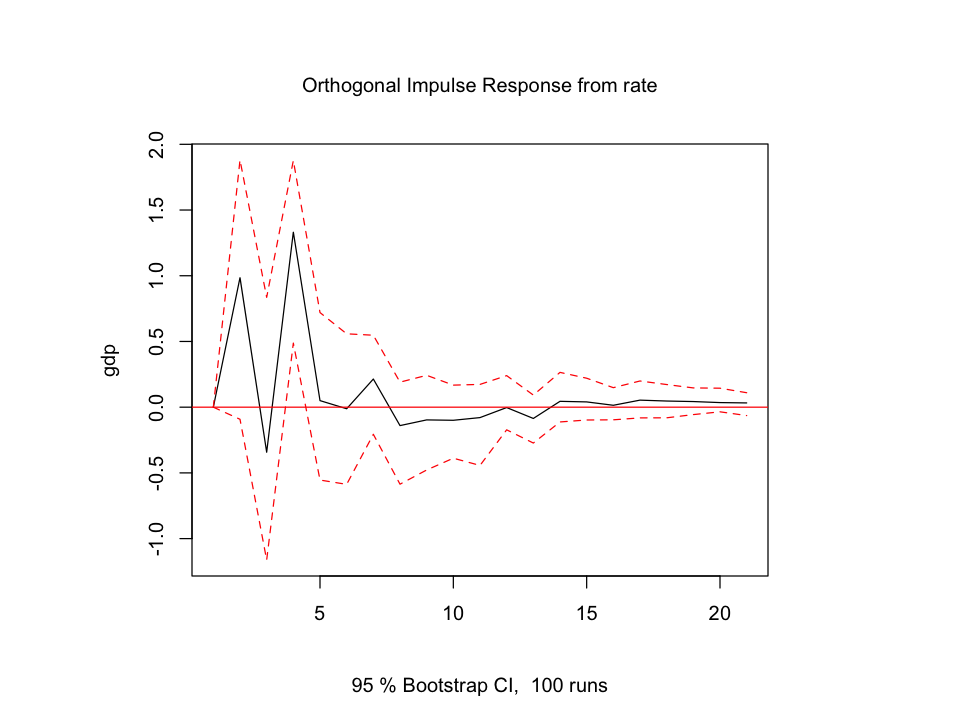

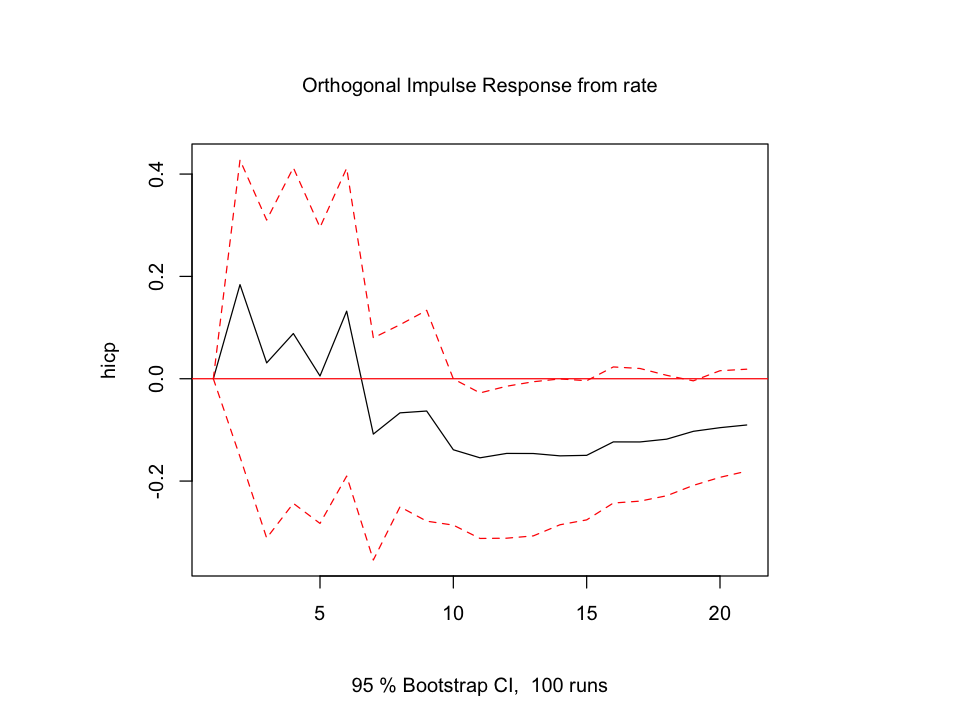

In [204]:
options(repr.plot.width = 8, repr.plot.height = 6)
plot(irf(model3,impulse = "rate", response = "gdp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))
plot(irf(model3,impulse = "rate", response = "hicp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))

## IRF with 6 lags

I try 6 lags, theoretically its the time of monetary transmission

In [222]:
model4 <- VAR(vardata2, p = 6, type = "const")
test <- serial.test(model4)
test$serial


	Portmanteau Test (asymptotic)

data:  Residuals of VAR object model4
Chi-squared = 182.59, df = 160, p-value = 0.1066


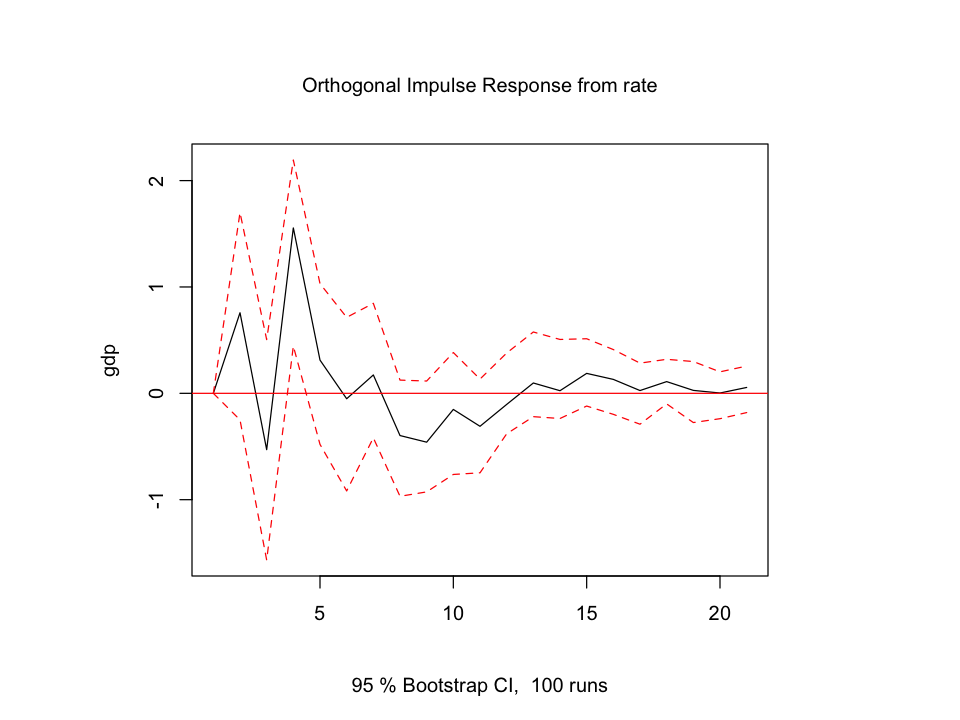

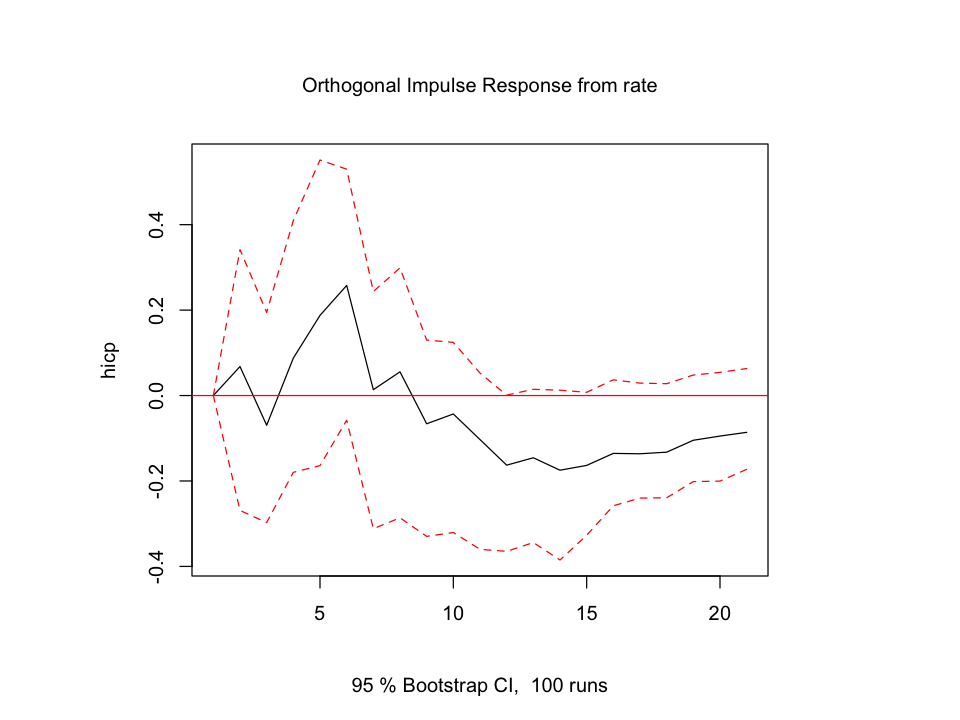

In [223]:
options(repr.plot.width = 8, repr.plot.height = 6)
plot(irf(model4,impulse = "rate", response = "gdp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))
plot(irf(model4,impulse = "rate", response = "hicp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))

based on results I'll keep the model with 4 lags

## FULL VAR model with 4 lags

In [30]:
model3 <- VAR(vardata2, p = 4, type = "const")
test <- serial.test(model3)
test$serial


	Portmanteau Test (asymptotic)

data:  Residuals of VAR object model3
Chi-squared = 214.86, df = 192, p-value = 0.1236


In [31]:
summary(model3)


VAR Estimation Results:
Endogenous variables: oil, gdp, hicp, rate 
Deterministic variables: const 
Sample size: 115 
Log Likelihood: -1201.416 
Roots of the characteristic polynomial:
0.8747 0.8747 0.7925 0.7925 0.7589 0.7589 0.7576 0.7576 0.6833 0.5986 0.5986 0.5717 0.5717 0.4647 0.4647 0.4262
Call:
VAR(y = vardata2, p = 4, type = "const")


Estimation results for equation oil: 
oil = oil.l1 + gdp.l1 + hicp.l1 + rate.l1 + oil.l2 + gdp.l2 + hicp.l2 + rate.l2 + oil.l3 + gdp.l3 + hicp.l3 + rate.l3 + oil.l4 + gdp.l4 + hicp.l4 + rate.l4 + const 

         Estimate Std. Error t value Pr(>|t|)  
oil.l1    0.35032    0.14237   2.461   0.0156 *
gdp.l1   -1.84597    1.32393  -1.394   0.1664  
hicp.l1  -3.22330    4.72801  -0.682   0.4970  
rate.l1  -6.51988   15.95705  -0.409   0.6837  
oil.l2   -0.11355    0.14939  -0.760   0.4491  
gdp.l2    0.82913    1.41904   0.584   0.5604  
hicp.l2   0.73615    5.35716   0.137   0.8910  
rate.l2   6.90490   25.19574   0.274   0.7846  
oil.l3    0.01625

The model is stable. We can se exogenous nature of oil prices. Interestingly, in gdp eq. there is a negative effect of past gdp on GDP. HICP is persistent and higly depens on past inflation and nominal IR depens on past inflation and own rate

## Forecasting

In [226]:
predict(model3, n.ahead = 12, ci = 0.95)

$oil
              fcst     lower     upper       CI
 [1,] -28.22354334 -154.3495  97.90237 126.1259
 [2,]  -0.68434850 -131.2217 129.85297 130.5373
 [3,]   0.09718756 -131.2191 131.41346 131.3163
 [4,]  -3.77887116 -137.6042 130.04648 133.8254
 [5,]   3.52408762 -131.2678 138.31595 134.7919
 [6,]   5.71342504 -129.2849 140.71171 134.9983
 [7,]   5.37040896 -130.1161 140.85695 135.4865
 [8,]   2.67523542 -132.9571 138.30754 135.6323
 [9,]   3.45455356 -132.2258 139.13491 135.6804
[10,]   5.52069655 -130.2503 141.29171 135.7710
[11,]   4.01925660 -131.7658 139.80429 135.7850
[12,]   3.90558221 -131.8815 139.69269 135.7871

$gdp
            fcst      lower     upper       CI
 [1,] -1.2941935 -11.948049  9.359662 10.65386
 [2,]  1.3452894  -9.963216 12.653795 11.30851
 [3,]  1.0475352 -10.357901 12.452971 11.40544
 [4,]  0.2592451 -11.543800 12.062290 11.80305
 [5,]  1.7440212 -10.267864 13.755906 12.01188
 [6,]  1.5825332 -10.439119 13.604185 12.02165
 [7,]  0.9452726 -11.120861 13.01140

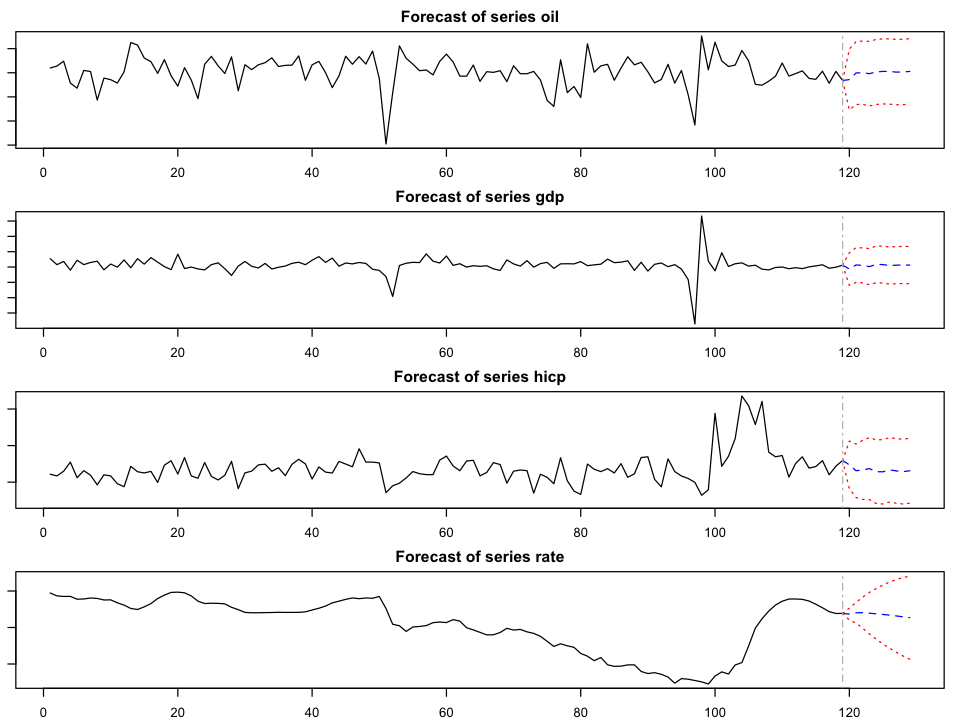

In [32]:
par(mar = c(2, 1, 2, 1))
plot(predict(model3))

For the model with 4 lags, there is no substantial explanatory forecast, just a likely trajectory to the mean. Compared to the univariate models, these results are much more plausible. In the univariate ARIMA model for GDP, I encountered a random walk problem, and for HICP, there were issues with autocorrelated residuals that forced me to use double differencing. The VAR model handles these dynamics much better.

## IMPULSE RESPONSE FUNCTION

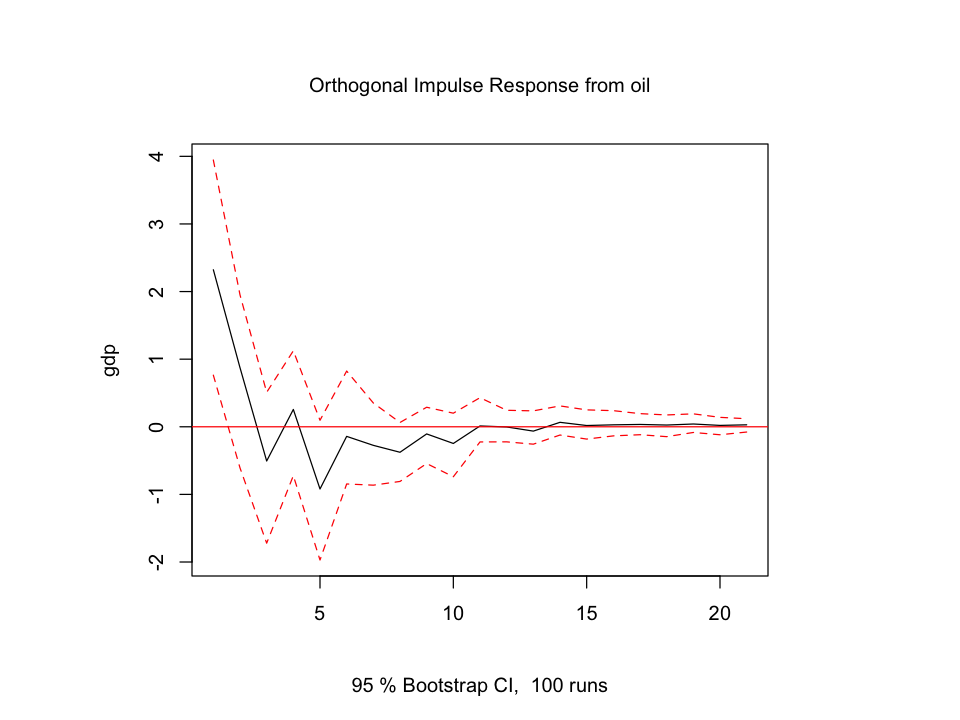

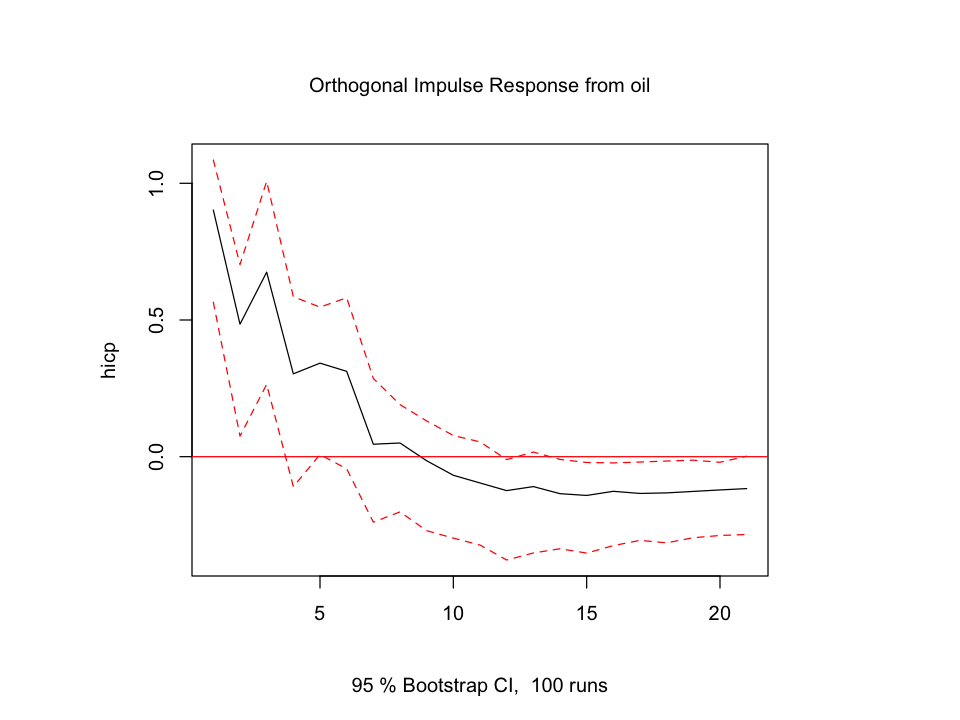

In [33]:
options(repr.plot.width = 8, repr.plot.height = 6)
plot(irf(model3,impulse = "oil", response = "gdp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))
plot(irf(model3,impulse = "oil", response = "hicp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))

An oil price shock initially has a positive effect on GDP, which subsequently fades out. Economic intuition would suggest the opposite, as Germany is heavily dependent on energy imports. On the other hand, the response of HICP is much more plausible, exhibiting a substantial positive effect that gradually declines over time.

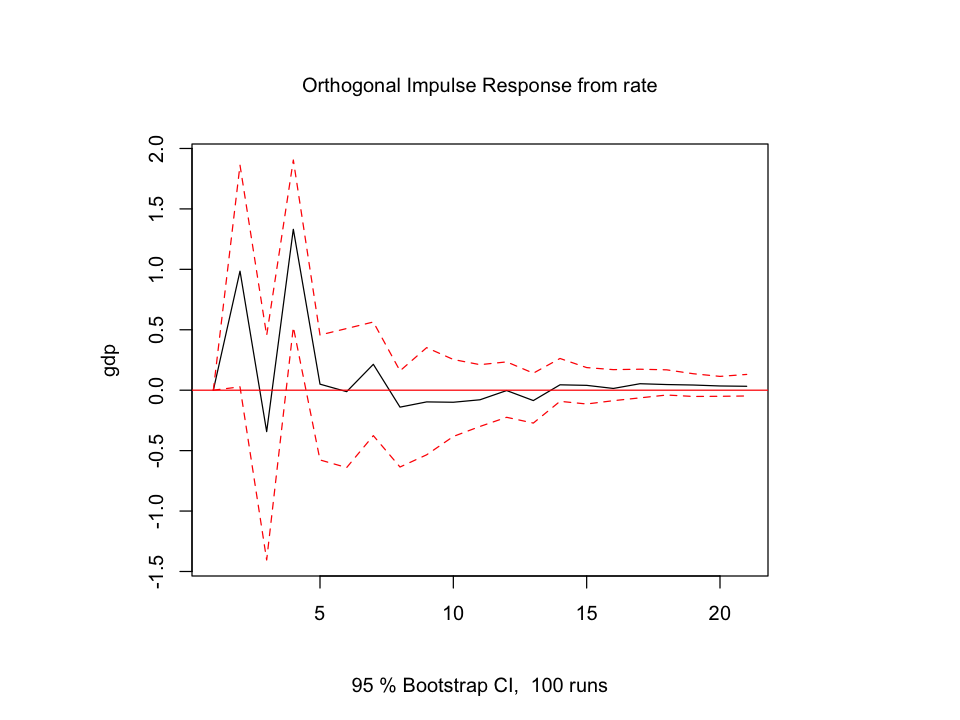

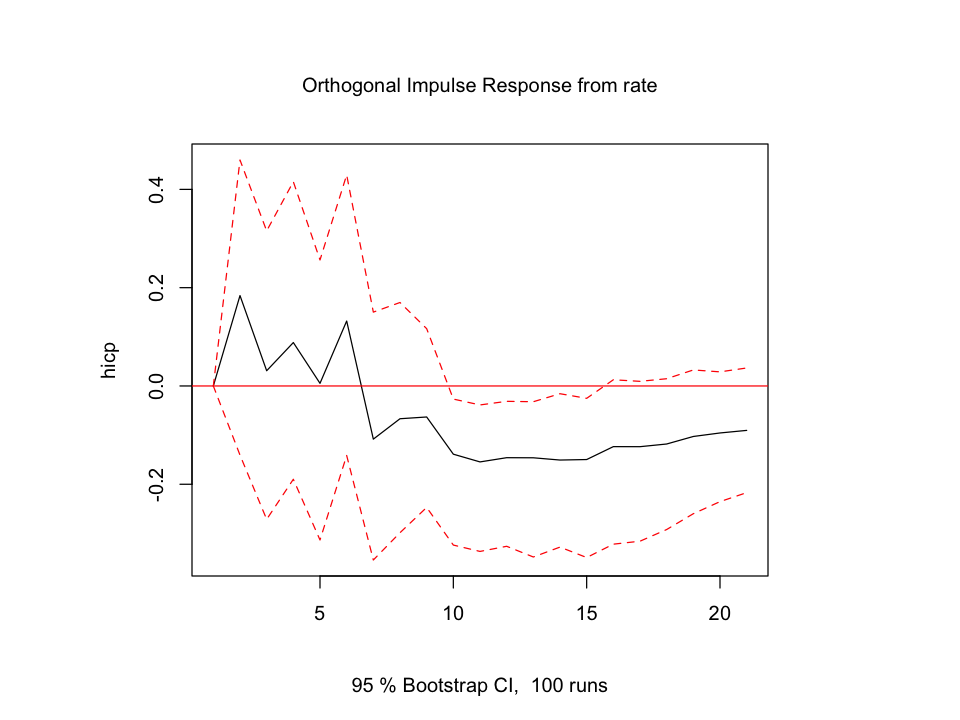

In [233]:
options(repr.plot.width = 8, repr.plot.height = 6)
plot(irf(model3,impulse = "rate", response = "gdp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))
plot(irf(model3,impulse = "rate", response = "hicp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))

The effect of a monetary policy shock on real GDP is unusual, showing no particular pattern as it fluctuates from period to period. Regarding inflation, there is an initial, statistically insignificant spike, followed by a statistically significant decline. This initial reaction clearly indicates the presence of a price puzzle

## Forecast error variance decomposition:

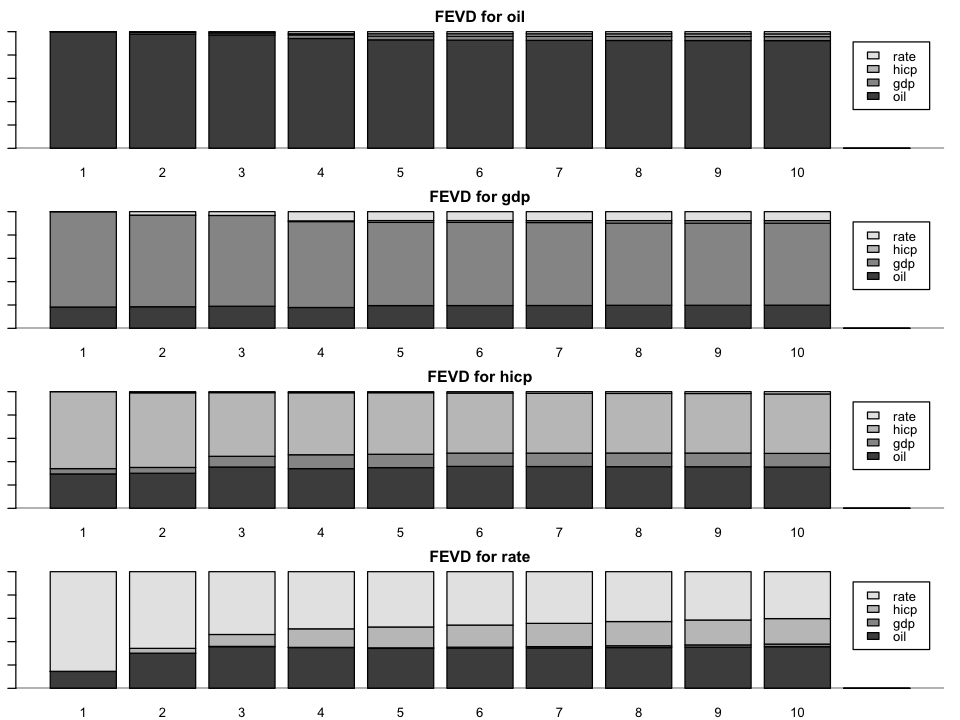

In [234]:
par(mar = c(2, 1, 2, 1))
plot(fevd(model3))

In the first graph, we can see the strict exogeneity of oil prices. Almost 100% of its variance is explained by its own shocks.

The second graph shows that real GDP is mostly explained by its own historical shocks. The monetary policy shock (interest rate) has almost no explanatory power here, which confirms our previous finding that the effect of interest rates on GDP is weak.

In the third graph, inflation is also driven mainly by its own past and by supply shocks (oil prices). Real GDP explains a small part of it (demand pressure).

The fourth graph is the most dynamic. In the short term, the interest rate is explained by its own shocks. But over the long term, inflation and GDP explain a large and growing portion of it. This shows that the central bankreacts to macroeconomic developments.

## Alternative SVAR model

In [46]:
amat <- diag(4)

amat[2, 1] <- NA  # gdp reaguje okamžitě na oil
amat[3, 1] <- NA  # hicp reaguje okamžitě na oil
amat[3, 2] <- NA  # hicp reaguje okamžitě na gdp

amat[4, 2] <- NA  # rate reaguje okamžitě na gdp
amat[4, 3] <- NA  # rate reaguje okamžitě na hicp
amat[4, 1] <- 0   # rate nereaguje okamžitě na oil 


print(amat)

bmat <- diag(4)
diag(bmat) <- NA
print(bmat)
# svar model
svar_oil_restricted <- SVAR(model3, estmethod = "scoring", Amat = amat, Bmat = bmat)
summary(svar_oil_restricted)

     [,1] [,2] [,3] [,4]
[1,]    1    0    0    0
[2,]   NA    1    0    0
[3,]   NA   NA    1    0
[4,]    0   NA   NA    1
     [,1] [,2] [,3] [,4]
[1,]   NA    0    0    0
[2,]    0   NA    0    0
[3,]    0    0   NA    0
[4,]    0    0    0   NA



SVAR Estimation Results:

Call:
SVAR(x = model3, estmethod = "scoring", Amat = amat, Bmat = bmat)

Type: AB-model 
Sample size: 115 
Log Likelihood: -1242.585 
Method: scoring 
Number of iterations: 69 

LR overidentification test:

	LR overidentification

data:  vardata2
Chi^2 = 8.8, df = 1, p-value = 0.003


Estimated A matrix:
          oil      gdp    hicp rate
oil   1.00000  0.00000  0.0000    0
gdp  -0.03609  1.00000  0.0000    0
hicp -0.01662  0.07220  1.0000    0
rate  0.00000 -0.01337 -0.0523    1

Estimated standard errors for A matrix:
          oil      gdp    hicp rate
oil  0.000000 0.000000 0.00000    0
gdp  0.007122 0.000000 0.00000    0
hicp 0.002163 0.025602 0.00000    0
rate 0.000000 0.006796 0.02223    0

Estimated B matrix:
       oil   gdp  hicp   rate
oil  64.35 0.000 0.000 0.0000
gdp   0.00 4.915 0.000 0.0000
hicp  0.00 0.000 1.349 0.0000
rate  0.00 0.000 0.000 0.3958

Estimated standard errors for B matrix:
       oil    gdp    hicp   rate
oil  4.243 0.0000 0.0

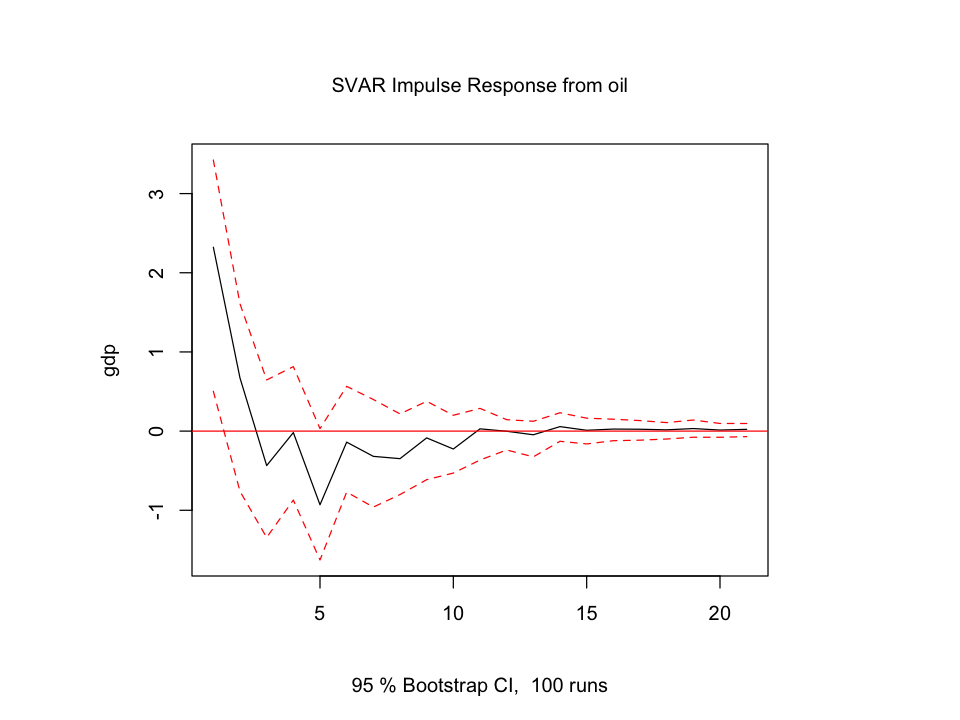

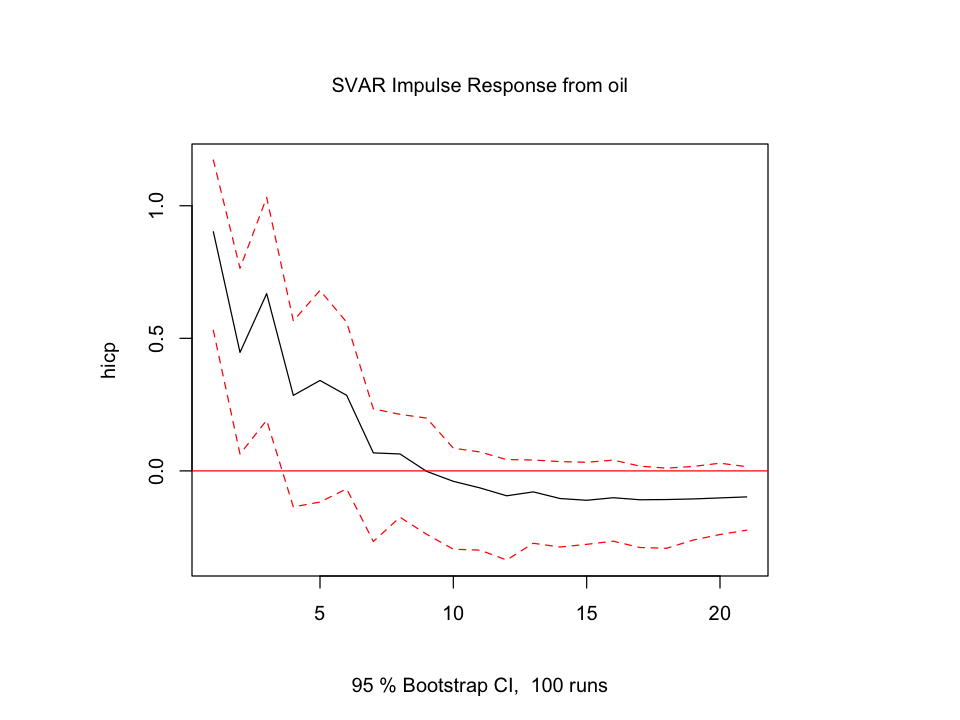

In [48]:
options(repr.plot.width = 8, repr.plot.height = 6)
plot(irf(svar_oil_restricted,impulse = "oil", response = "gdp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))
plot(irf(svar_oil_restricted,impulse = "oil", response = "hicp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))

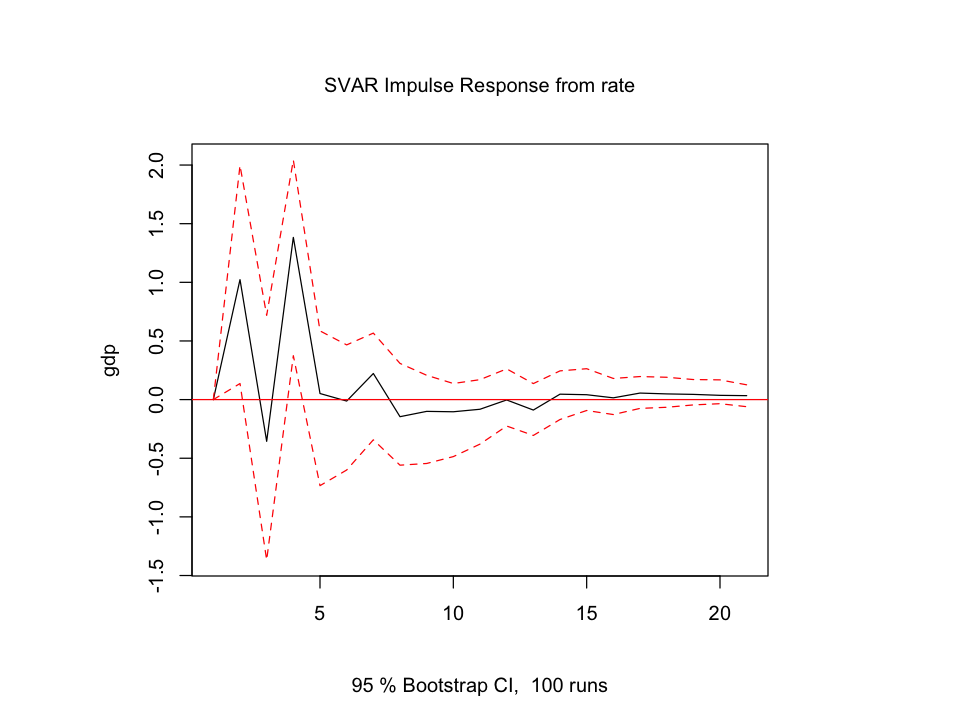

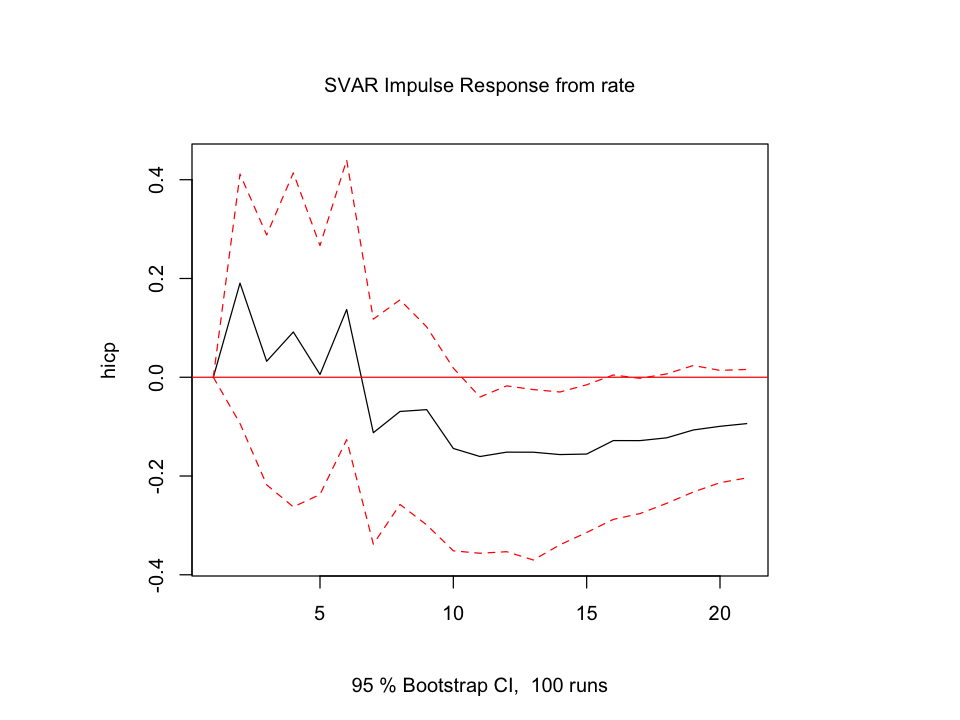

In [49]:
options(repr.plot.width = 8, repr.plot.height = 6)
plot(irf(svar_oil_restricted,impulse = "rate", response = "gdp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))
plot(irf(svar_oil_restricted,impulse = "rate", response = "hicp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))

In [235]:
vardata_alt <- data[,c("oil", "rate", "gdp", "hicp")]

VAR lag selection and summary should be the same thus a will plot only the IRF's

In [47]:
model2_alt <- VAR(vardata_alt, p = 4, type = "const")

plot(irf(model2_alt, impulse = "rate", response = "gdp", n.ahead = 20, 
         ci = 0.95, cumulative = F, boot = T, ortho = T))

plot(irf(model2_alt, impulse = "rate", response = "hicp", n.ahead = 20, ci = 0.95,
              cumulative = F, boot = T, ortho = T))

ERROR: Error: object 'vardata_alt' not found


We can see that the responses do not start from zero, meaning that GDP and HICP are responding to monetary policy in the same period. However, the overall trajectory is the same as in the previous model, which indicates the robustness of our estimation.